In [2]:
import pykep as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.graph_objects as go

In [3]:
import urllib.request

urls = [
    "https://gtoc.jpl.net/static/gtoc13/gtoc13_planets.csv",
    "https://gtoc.jpl.net/static/gtoc13/gtoc13_asteroids.csv",
    "https://gtoc.jpl.net/static/gtoc13/gtoc13_comets.csv"
]

for url in urls:
    filename = url.split("/")[-1]
    urllib.request.urlretrieve(url, filename)
    print(f"Downloaded {filename}")


Downloaded gtoc13_planets.csv
Downloaded gtoc13_asteroids.csv
Downloaded gtoc13_comets.csv


In [4]:
print(pk.__version__)
from pykep import AU, DAY2SEC, MU_SUN

print("1 AU in meters:", AU)
print("1 day in seconds:", DAY2SEC)
print("Sun gravitational parameter:", MU_SUN)

{'major': 2, 'minor': 6}
1 AU in meters: 149597870691.0
1 day in seconds: 86400.0
Sun gravitational parameter: 1.32712440018e+20


In [41]:

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the data
planets = pd.read_csv('./content/gtoc13_planets.csv', encoding='latin1')
asteroids = pd.read_csv('./content/gtoc13_asteroids.csv', encoding='latin1')
comets = pd.read_csv('./content/gtoc13_comets.csv', encoding='latin1')

# Constants
AU = 149597870.691  # km
MU_ALTAIRA = 139348062043.343  # km³/s²
YEAR_SEC = 365.25 * 86400  # seconds
DEG2RAD = np.pi / 180

print("=== GTOC13 SYSTEM OVERVIEW ===")
print(f"Number of planets: {len(planets)}")
print(f"Number of asteroids: {len(asteroids)}")
print(f"Number of comets: {len(comets)}")
print(f"Total bodies: {len(planets) + len(asteroids) + len(comets)}")

=== GTOC13 SYSTEM OVERVIEW ===
Number of planets: 11
Number of asteroids: 257
Number of comets: 42
Total bodies: 310


In [6]:
# 1. SYSTEM ARCHITECTURE ANALYSIS

def calculate_orbital_period(semi_major_axis_km):
    """Calculate orbital period in years"""
    a = semi_major_axis_km  # km
    return 2 * np.pi * np.sqrt(a**3 / MU_ALTAIRA) / YEAR_SEC

def calculate_orbital_velocity(semi_major_axis_km, distance_km=None):
    """Calculate orbital velocity at given distance"""
    if distance_km is None:
        distance_km = semi_major_axis_km
    return np.sqrt(MU_ALTAIRA * (2/distance_km - 1/semi_major_axis_km))

# Add orbital periods to all bodies
planets['orbital_period_yrs'] = calculate_orbital_period(planets['Semi-Major Axis (km)'])
asteroids['orbital_period_yrs'] = calculate_orbital_period(asteroids['Semi-Major Axis (km)'])
comets['orbital_period_yrs'] = calculate_orbital_period(comets['Semi-Major Axis (km)'])

# Convert semi-major axis to AU for easier interpretation
planets['semi_major_axis_AU'] = planets['Semi-Major Axis (km)'] / AU
asteroids['semi_major_axis_AU'] = asteroids['Semi-Major Axis (km)'] / AU
comets['semi_major_axis_AU'] = comets['Semi-Major Axis (km)'] / AU

print("\n=== PLANETARY SYSTEM ANALYSIS ===")
print("Planets by semi-major axis (AU):")
for _, planet in planets.sort_values('semi_major_axis_AU').iterrows():
    print(f"{planet['Name']:12} | a = {planet['semi_major_axis_AU']:8.3f} AU | "
          f"P = {planet['orbital_period_yrs']:6.3f} yrs | "
          f"w = {planet['Weight ()']} | e = {planet['Eccentricity ()']:.3f}")


=== PLANETARY SYSTEM ANALYSIS ===
Planets by semi-major axis (AU):
Vulcan       | a =    0.092 AU | P =  0.027 yrs | w = 0.1 | e = 0.000
Yavin        | a =    0.859 AU | P =  0.777 yrs | w = 1.0 | e = 0.050
Eden         | a =    1.200 AU | P =  1.283 yrs | w = 2.0 | e = 0.007
Hoth         | a =    2.939 AU | P =  4.916 yrs | w = 3.0 | e = 0.050
Yandi        | a =    3.986 AU | P =  7.767 yrs | w = 5.0 | e = 0.077
Beyoncé      | a =    7.481 AU | P = 19.968 yrs | w = 7.0 | e = 0.070
Bespin       | a =   14.295 AU | P = 52.748 yrs | w = 10.0 | e = 0.119
Jotunn       | a =   17.529 AU | P = 71.623 yrs | w = 15.0 | e = 0.150
Wakonyingo   | a =   34.195 AU | P = 195.145 yrs | w = 20.0 | e = 0.095
Rogue1       | a =   67.173 AU | P = 537.289 yrs | w = 35.0 | e = 0.100
PlanetX      | a =  106.653 AU | P = 1074.908 yrs | w = 50.0 | e = 0.345


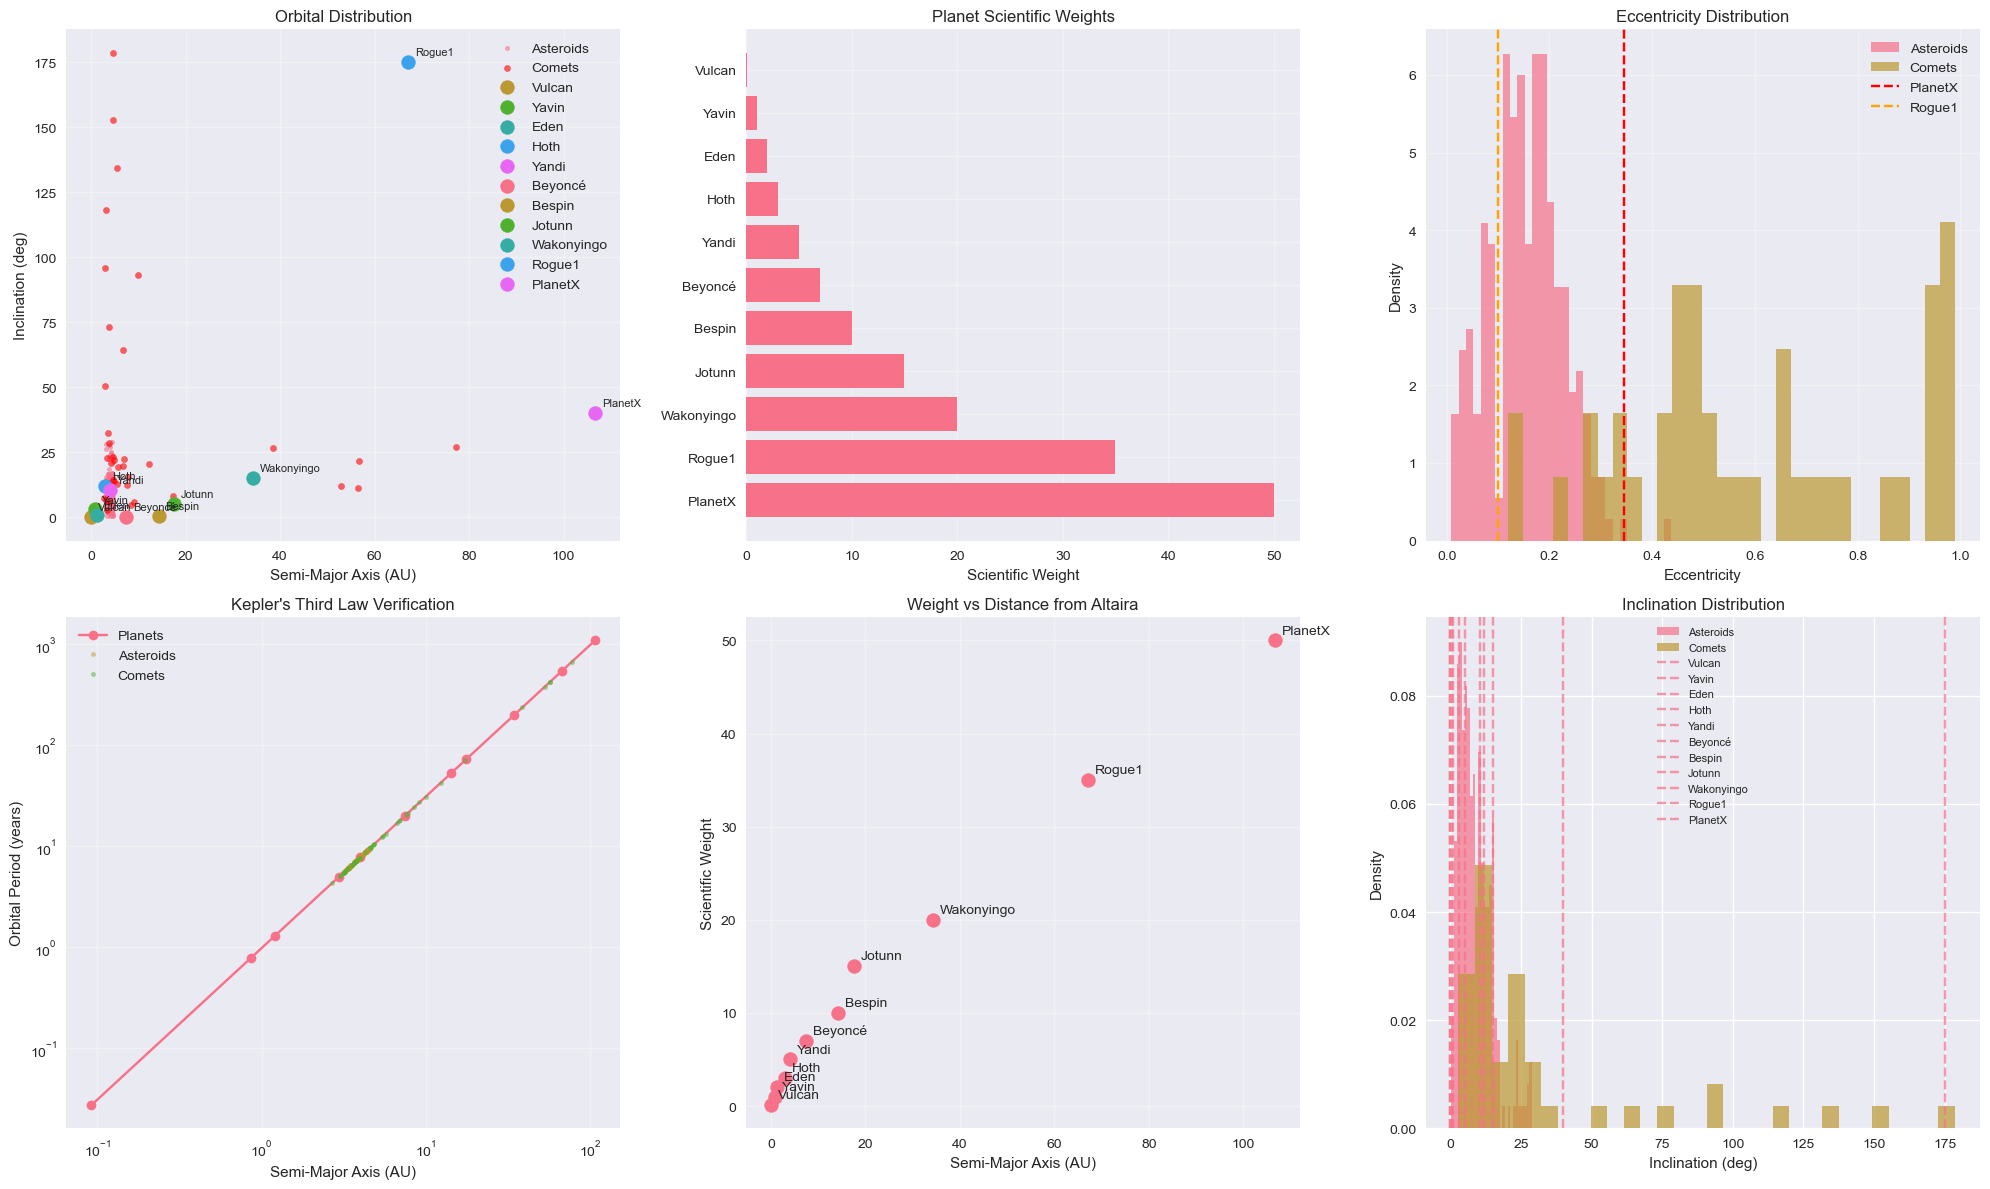

In [7]:
# Create comprehensive system visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Semi-major axis distribution
all_bodies = pd.concat([
    planets[['semi_major_axis_AU', 'Weight ()', 'Name']].assign(type='Planet'),
    asteroids[['semi_major_axis_AU', 'Weight ()']].assign(type='Asteroid', Name=''),
    comets[['semi_major_axis_AU', 'Weight ()']].assign(type='Comet', Name='')
])

axes[0,0].scatter(asteroids['semi_major_axis_AU'], asteroids['Inclination (deg)'],
                 alpha=0.6, s=10, label='Asteroids')
axes[0,0].scatter(comets['semi_major_axis_AU'], comets['Inclination (deg)'],
                 alpha=0.6, s=20, label='Comets', color='red')
for _, planet in planets.iterrows():
    axes[0,0].scatter(planet['semi_major_axis_AU'], planet['Inclination (deg)'],
                     s=100, label=planet['Name'])
    axes[0,0].annotate(planet['Name'],
                      (planet['semi_major_axis_AU'], planet['Inclination (deg)']),
                      xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[0,0].set_xlabel('Semi-Major Axis (AU)')
axes[0,0].set_ylabel('Inclination (deg)')
axes[0,0].set_title('Orbital Distribution')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Weight distribution
weights_data = []
for _, planet in planets.iterrows():
    weights_data.append({'Name': planet['Name'], 'Weight': planet['Weight ()'], 'Type': 'Planet'})
for _, asteroid in asteroids.iterrows():
    weights_data.append({'Name': f"Asteroid {asteroid['#Asteroid ID']}",
                       'Weight': asteroid['Weight ()'], 'Type': 'Asteroid'})
for _, comet in comets.iterrows():
    weights_data.append({'Name': f"Comet {comet['# Comet ID']}",
                       'Weight': comet['Weight ()'], 'Type': 'Comet'})
weights_df = pd.DataFrame(weights_data)

planet_weights = planets[['Name', 'Weight ()']].sort_values('Weight ()', ascending=False)
axes[0,1].barh(planet_weights['Name'], planet_weights['Weight ()'])
axes[0,1].set_xlabel('Scientific Weight')
axes[0,1].set_title('Planet Scientific Weights')
axes[0,1].grid(True, alpha=0.3)

# 3. Eccentricity distribution
axes[0,2].hist(asteroids['Eccentricity ()'], bins=30, alpha=0.7, label='Asteroids', density=True)
axes[0,2].hist(comets['Eccentricity ()'], bins=30, alpha=0.7, label='Comets', density=True)
axes[0,2].axvline(planets.loc[planets['Name'] == 'PlanetX', 'Eccentricity ()'].values[0],
                 color='red', linestyle='--', label='PlanetX')
axes[0,2].axvline(planets.loc[planets['Name'] == 'Rogue1', 'Eccentricity ()'].values[0],
                 color='orange', linestyle='--', label='Rogue1')
axes[0,2].set_xlabel('Eccentricity')
axes[0,2].set_ylabel('Density')
axes[0,2].set_title('Eccentricity Distribution')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. Orbital period vs semi-major axis (log-log)
axes[1,0].loglog(planets['semi_major_axis_AU'], planets['orbital_period_yrs'], 'o-', label='Planets')
axes[1,0].loglog(asteroids['semi_major_axis_AU'], asteroids['orbital_period_yrs'], '.',
                alpha=0.5, label='Asteroids')
axes[1,0].loglog(comets['semi_major_axis_AU'], comets['orbital_period_yrs'], '.',
                alpha=0.5, label='Comets')
axes[1,0].set_xlabel('Semi-Major Axis (AU)')
axes[1,0].set_ylabel('Orbital Period (years)')
axes[1,0].set_title('Kepler\'s Third Law Verification')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5. Weight vs accessibility (semi-major axis)
axes[1,1].scatter(planets['semi_major_axis_AU'], planets['Weight ()'], s=100)
for _, planet in planets.iterrows():
    axes[1,1].annotate(planet['Name'],
                      (planet['semi_major_axis_AU'], planet['Weight ()']),
                      xytext=(5, 5), textcoords='offset points')
axes[1,1].set_xlabel('Semi-Major Axis (AU)')
axes[1,1].set_ylabel('Scientific Weight')
axes[1,1].set_title('Weight vs Distance from Altaira')
axes[1,1].grid(True, alpha=0.3)

# 6. Inclination distribution
axes[1,2].hist(asteroids['Inclination (deg)'], bins=30, alpha=0.7, label='Asteroids', density=True)
axes[1,2].hist(comets['Inclination (deg)'], bins=30, alpha=0.7, label='Comets', density=True)
for _, planet in planets.iterrows():
    axes[1,2].axvline(planet['Inclination (deg)'], linestyle='--',
                     label=planet['Name'], alpha=0.7)
axes[1,2].set_xlabel('Inclination (deg)')
axes[1,2].set_ylabel('Density')
axes[1,2].set_title('Inclination Distribution')
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.show()


=== GRAND TOUR BONUS REQUIREMENTS ===
Required: Flybys of all 12 major bodies (planets + Yandi)
Required: At least 13 asteroid/comet flybys
Bonus: 1.2x multiplier (20% increase)


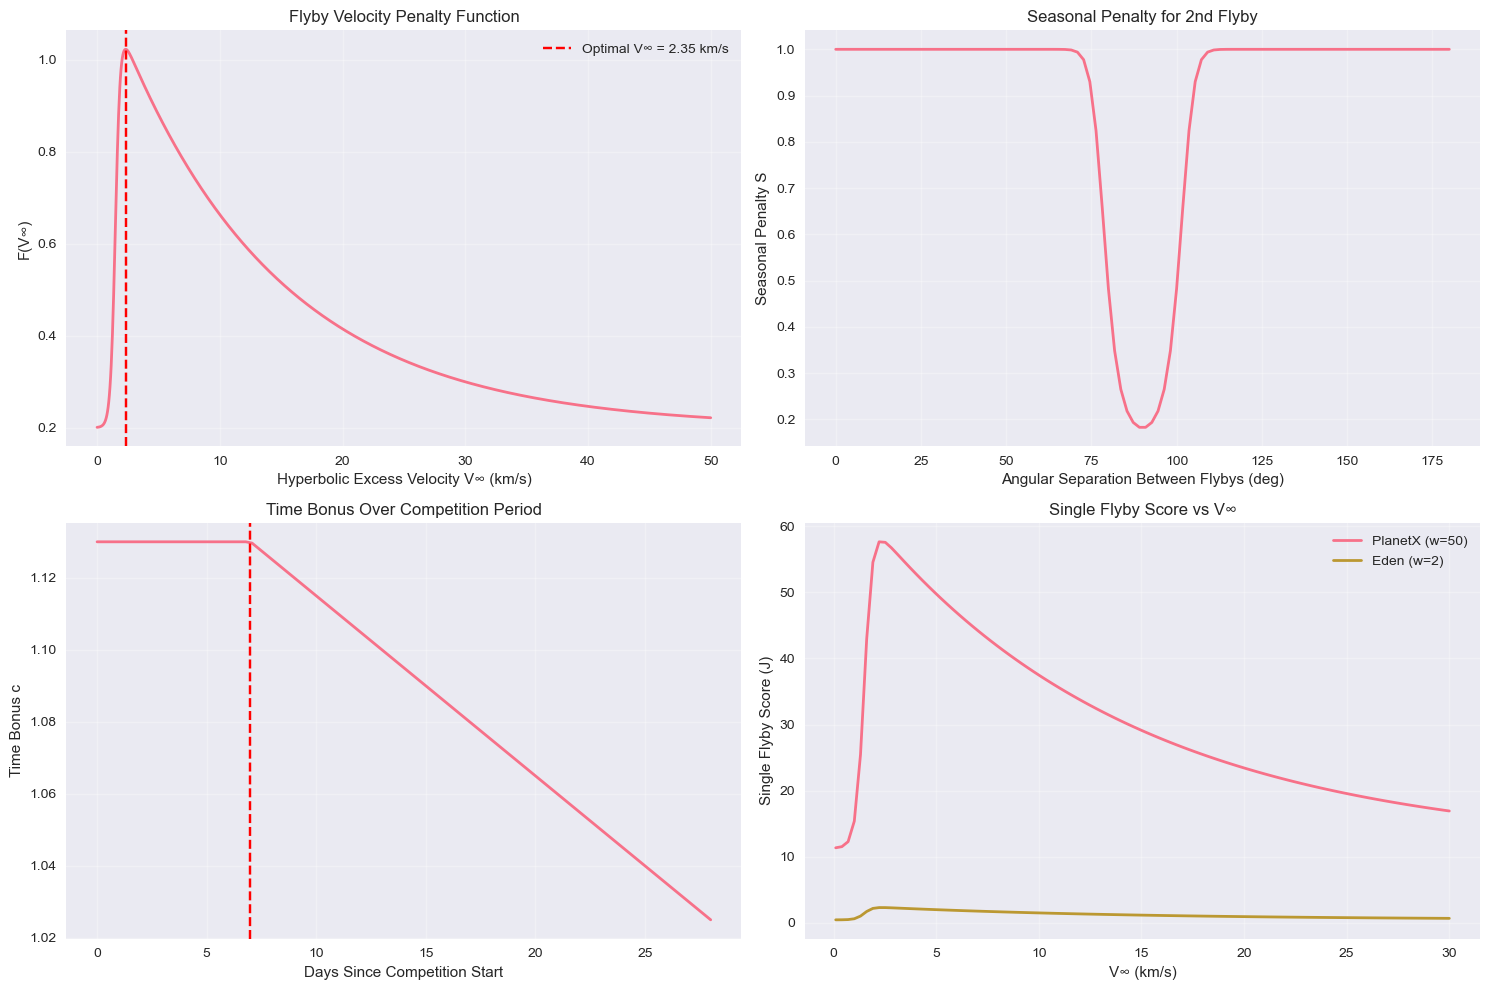

In [8]:
# 2. OBJECTIVE FUNCTION ANALYSIS

def seasonal_penalty(r_vectors):
    """Calculate seasonal penalty S for multiple flybys"""
    # r_vectors: list of unit position vectors for flybys of the same body
    if len(r_vectors) == 1:
        return 1.0

    S_values = []
    for i in range(len(r_vectors)):
        if i == 0:
            S_values.append(1.0)
        else:
            sum_term = 0
            for j in range(i):
                angle_deg = np.degrees(np.arccos(np.clip(np.dot(r_vectors[i], r_vectors[j]), -1, 1)))
                sum_term += 10 * np.exp(-angle_deg**2 / 50)
            S_values.append(0.1 + 0.9 / (1 + sum_term))
    return S_values

def flyby_velocity_penalty(V_inf):
    """Calculate flyby velocity penalty F(V∞)"""
    return 0.2 + np.exp(-V_inf/13) / (1 + np.exp(-5*(V_inf - 1.5)))

# Analyze objective function components
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Flyby velocity penalty
V_inf_range = np.linspace(0, 50, 1000)
F_values = flyby_velocity_penalty(V_inf_range)
axes[0,0].plot(V_inf_range, F_values, linewidth=2)
axes[0,0].set_xlabel('Hyperbolic Excess Velocity V∞ (km/s)')
axes[0,0].set_ylabel('F(V∞)')
axes[0,0].set_title('Flyby Velocity Penalty Function')
axes[0,0].grid(True, alpha=0.3)

# Mark optimal regions
optimal_V = V_inf_range[np.argmax(F_values)]
axes[0,0].axvline(optimal_V, color='red', linestyle='--',
                 label=f'Optimal V∞ = {optimal_V:.2f} km/s')
axes[0,0].legend()

# 2. Seasonal penalty analysis
# Simulate different angular separations
angles = np.linspace(0, 180, 100)
S_2nd_flyby = []
for angle in angles:
    r1 = np.array([0, 1, 0])
    r2 = np.array([np.cos(np.radians(angle)), np.sin(np.radians(angle)), 0])
    S = seasonal_penalty([r1, r2])[1]
    S_2nd_flyby.append(S)

axes[0,1].plot(angles, S_2nd_flyby, linewidth=2)
axes[0,1].set_xlabel('Angular Separation Between Flybys (deg)')
axes[0,1].set_ylabel('Seasonal Penalty S')
axes[0,1].set_title('Seasonal Penalty for 2nd Flyby')
axes[0,1].grid(True, alpha=0.3)

# 3. Grand tour bonus analysis
required_bodies = len(planets) + 1  # All planets + Yandi
required_small_bodies = 13  # Asteroids or comets
print(f"\n=== GRAND TOUR BONUS REQUIREMENTS ===")
print(f"Required: Flybys of all {required_bodies} major bodies (planets + Yandi)")
print(f"Required: At least {required_small_bodies} asteroid/comet flybys")
print(f"Bonus: 1.2x multiplier (20% increase)")

# 4. Time bonus analysis
competition_days = np.linspace(0, 28, 100)
time_bonus = np.where(competition_days <= 7, 1.13, -0.005 * competition_days + 1.165)
axes[1,0].plot(competition_days, time_bonus, linewidth=2)
axes[1,0].set_xlabel('Days Since Competition Start')
axes[1,0].set_ylabel('Time Bonus c')
axes[1,0].set_title('Time Bonus Over Competition Period')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].axvline(7, color='red', linestyle='--', label='Bonus decay starts')

# 5. Combined score analysis for single flyby example
V_example = np.linspace(0.1, 30, 100)
score_planetX = 50 * flyby_velocity_penalty(V_example) * 1.13  # Assuming early submission, no grand tour
score_Eden = 2 * flyby_velocity_penalty(V_example) * 1.13

axes[1,1].plot(V_example, score_planetX, label='PlanetX (w=50)', linewidth=2)
axes[1,1].plot(V_example, score_Eden, label='Eden (w=2)', linewidth=2)
axes[1,1].set_xlabel('V∞ (km/s)')
axes[1,1].set_ylabel('Single Flyby Score (J)')
axes[1,1].set_title('Single Flyby Score vs V∞')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# 3. RESONANCE AND ORBITAL MECHANICS ANALYSIS

def find_orbital_resonances(periods, tolerance=0.02):
    """Find potential orbital resonances between bodies"""
    resonances = []
    n_bodies = len(periods)

    for i in range(n_bodies):
        for j in range(i+1, n_bodies):
            ratio = periods[i] / periods[j]

            # Check for simple integer ratios
            for m in range(1, 6):
                for n in range(1, 6):
                    if m != n:  # Avoid 1:1
                        theoretical = m/n
                        if abs(ratio - theoretical) < tolerance:
                            resonances.append({
                                'body1_idx': i, 'body2_idx': j,
                                'period1': periods[i], 'period2': periods[j],
                                'ratio': ratio, 'resonance': f'{m}:{n}',
                                'error': abs(ratio - theoretical)
                            })

    return pd.DataFrame(resonances)

# Analyze planet resonances
planet_periods = planets['orbital_period_yrs'].values
planet_resonances = find_orbital_resonances(planet_periods)

print("\n=== ORBITAL RESONANCES ===")
print("Known resonances from problem statement:")
print("Rogue1 : PlanetX = 2:1 resonance")

for _, res in planet_resonances.iterrows():
    body1 = planets.iloc[res['body1_idx']]['Name']
    body2 = planets.iloc[res['body2_idx']]['Name']
    print(f"{body1:12} : {body2:12} = {res['resonance']:4} "
          f"(actual: {res['ratio']:.3f}, error: {res['error']:.3f})")

# Calculate synodic periods
def synodic_period(P1, P2):
    """Calculate synodic period between two orbits"""
    return 1 / abs(1/P1 - 1/P2)

print("\n=== SYNODIC PERIODS (years) ===")
for i in range(len(planets)):
    for j in range(i+1, len(planets)):
        P1 = planets.iloc[i]['orbital_period_yrs']
        P2 = planets.iloc[j]['orbital_period_yrs']
        synodic = synodic_period(P1, P2)
        if synodic < 100:  # Only show reasonably short synodic periods
            print(f"{planets.iloc[i]['Name']:12} - {planets.iloc[j]['Name']:12}: {synodic:6.1f} yrs")


=== ORBITAL RESONANCES ===
Known resonances from problem statement:
Rogue1 : PlanetX = 2:1 resonance
Yavin        : Eden         = 3:5  (actual: 0.606, error: 0.006)
Eden         : Hoth         = 1:4  (actual: 0.261, error: 0.011)
Hoth         : Beyoncé      = 1:4  (actual: 0.246, error: 0.004)
Yandi        : Beyoncé      = 2:5  (actual: 0.389, error: 0.011)
Bespin       : Jotunn       = 3:4  (actual: 0.736, error: 0.014)
Wakonyingo   : PlanetX      = 1:5  (actual: 0.182, error: 0.018)
Rogue1       : PlanetX      = 1:2  (actual: 0.500, error: 0.000)
Rogue1       : PlanetX      = 2:4  (actual: 0.500, error: 0.000)

=== SYNODIC PERIODS (years) ===
Vulcan       - Yavin       :    0.0 yrs
Vulcan       - Eden        :    0.0 yrs
Vulcan       - Hoth        :    0.0 yrs
Vulcan       - Yandi       :    0.0 yrs
Vulcan       - Beyoncé     :    0.0 yrs
Vulcan       - Bespin      :    0.0 yrs
Vulcan       - Jotunn      :    0.0 yrs
Vulcan       - Wakonyingo  :    0.0 yrs
Vulcan       - Rogue1    


=== SIMPLIFIED DELTA-V ANALYSIS (km/s) ===
Hohmann transfer delta-V between planets:
Yavin        -> Eden        :   5.03 km/s
Eden         -> Yavin       :   5.03 km/s
Eden         -> Hoth        :   9.59 km/s
Hoth         -> Eden        :   9.59 km/s
Hoth         -> Yandi       :   2.50 km/s
Hoth         -> Beyoncé     :   6.31 km/s
Hoth         -> Bespin      :   8.49 km/s
Hoth         -> Jotunn      :   8.88 km/s
Hoth         -> Wakonyingo  :   9.50 km/s
Hoth         -> Rogue1      :   9.49 km/s
Hoth         -> PlanetX     :   9.31 km/s
Yandi        -> Hoth        :   2.50 km/s
Yandi        -> Beyoncé     :   4.03 km/s
Yandi        -> Bespin      :   6.57 km/s
Yandi        -> Jotunn      :   7.08 km/s
Yandi        -> Wakonyingo  :   8.01 km/s
Yandi        -> Rogue1      :   8.20 km/s
Yandi        -> PlanetX     :   8.10 km/s
Beyoncé      -> Hoth        :   6.31 km/s
Beyoncé      -> Yandi       :   4.03 km/s
Beyoncé      -> Bespin      :   3.01 km/s
Beyoncé      -> Jotunn      :   

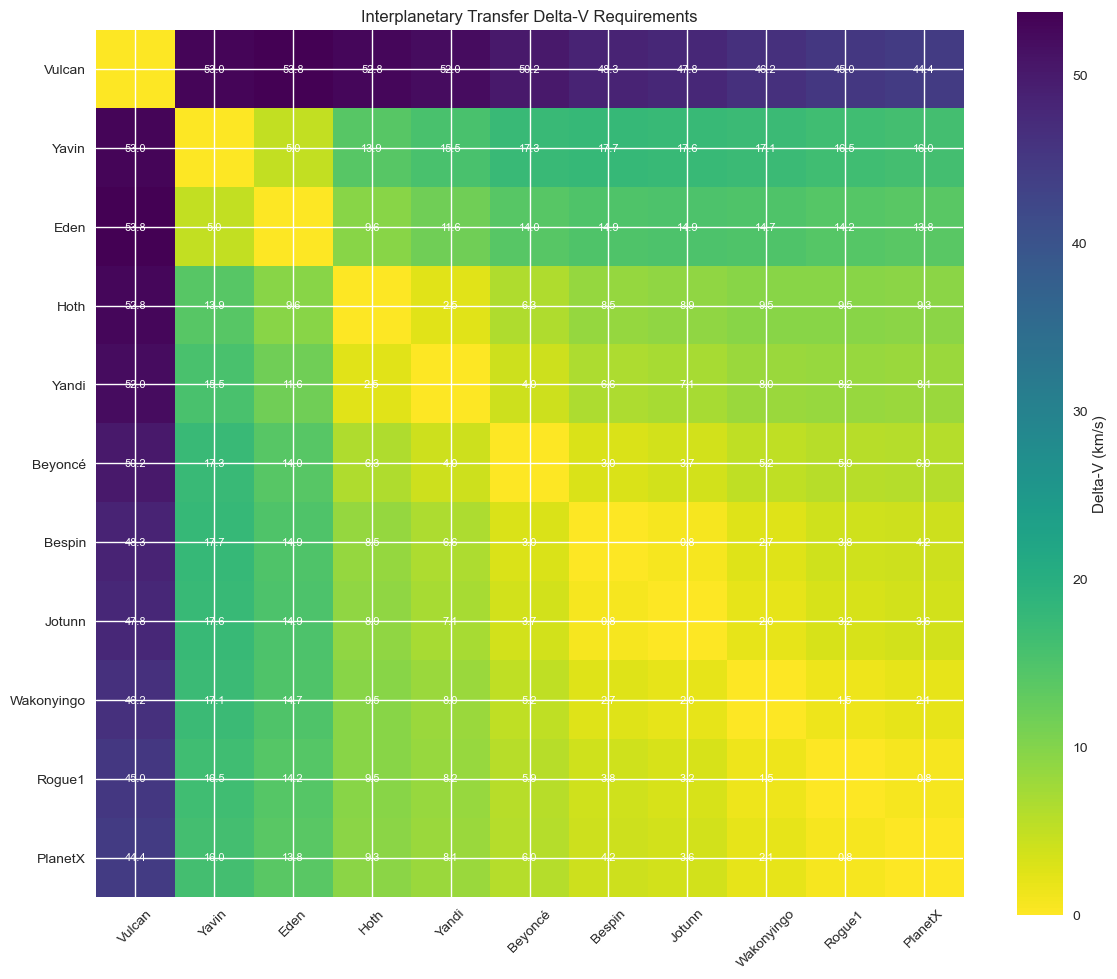

In [10]:
# 4. ACCESSIBILITY AND DELTA-V ANALYSIS

def circular_orbital_velocity(distance_km):
    """Calculate circular orbital velocity at given distance"""
    return np.sqrt(MU_ALTAIRA / distance_km)

def hohmann_transfer_deltaV(r1, r2):
    """Calculate delta-V for Hohmann transfer between circular orbits"""
    a_transfer = (r1 + r2) / 2
    v1 = circular_orbital_velocity(r1)
    v2 = circular_orbital_velocity(r2)

    v1_transfer = np.sqrt(MU_ALTAIRA * (2/r1 - 1/a_transfer))
    v2_transfer = np.sqrt(MU_ALTAIRA * (2/r2 - 1/a_transfer))

    deltaV1 = abs(v1_transfer - v1)
    deltaV2 = abs(v2 - v2_transfer)

    return deltaV1 + deltaV2

# Analyze transfer requirements between major planets
planet_distances = planets['Semi-Major Axis (km)'].values
planet_names = planets['Name'].values

print("\n=== SIMPLIFIED DELTA-V ANALYSIS (km/s) ===")
print("Hohmann transfer delta-V between planets:")

deltaV_matrix = np.zeros((len(planets), len(planets)))
for i in range(len(planets)):
    for j in range(len(planets)):
        if i != j:
            deltaV = hohmann_transfer_deltaV(planet_distances[i], planet_distances[j])
            deltaV_matrix[i,j] = deltaV
            if deltaV < 10:  # Only show feasible transfers
                print(f"{planet_names[i]:12} -> {planet_names[j]:12}: {deltaV:6.2f} km/s")

# Create delta-V heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(deltaV_matrix, cmap='viridis_r')

ax.set_xticks(range(len(planets)))
ax.set_yticks(range(len(planets)))
ax.set_xticklabels(planet_names, rotation=45)
ax.set_yticklabels(planet_names)

# Add text annotations
for i in range(len(planets)):
    for j in range(len(planets)):
        if i != j and deltaV_matrix[i,j] > 0:
            text = ax.text(j, i, f'{deltaV_matrix[i,j]:.1f}',
                          ha="center", va="center", color="w", fontsize=8)

plt.colorbar(im, label='Delta-V (km/s)')
plt.title('Interplanetary Transfer Delta-V Requirements')
plt.tight_layout()
plt.show()

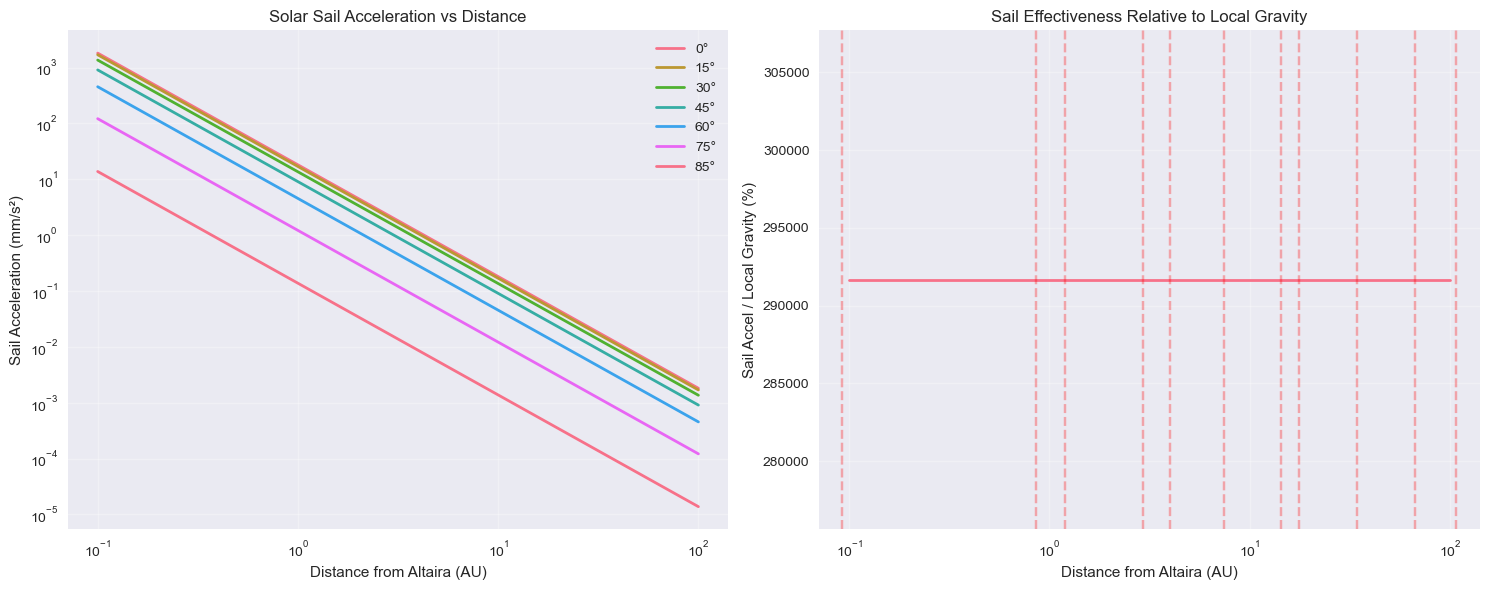


=== SOLAR SAIL PERFORMANCE AT KEY LOCATIONS ===
At  0.1 AU: Sail accel = 1816.0000 mm/s² (291652.5% of local gravity)
At  1.0 AU: Sail accel =  18.1600 mm/s² (291652.5% of local gravity)
At  5.0 AU: Sail accel =   0.7264 mm/s² (291652.5% of local gravity)
At 13.0 AU: Sail accel =   0.1075 mm/s² (291652.5% of local gravity)
At 50.0 AU: Sail accel =   0.0073 mm/s² (291652.5% of local gravity)
At 100.0 AU: Sail accel =   0.0018 mm/s² (291652.5% of local gravity)


In [11]:
# 5. SOLAR SAIL PERFORMANCE ANALYSIS

# Solar sail parameters from problem
C = 9.08e-6  # N/m² (Solar radiation pressure at 1 AU for Altaira)
A = 1e6      # m² (Sail area - example)
m = 1000     # kg (Spacecraft mass - example)

def solar_sail_acceleration(distance_AU, cone_angle_deg):
    """Calculate solar sail acceleration"""
    r_km = distance_AU * AU
    r0_km = 1 * AU

    alpha_rad = np.radians(cone_angle_deg)
    acceleration = (2 * C * A / m) * (r0_km / r_km)**2 * (np.cos(alpha_rad))**2

    return acceleration * 1000  # Convert to mm/s²

# Analyze sail performance
distances_AU = np.logspace(-1, 2, 50)  # 0.1 AU to 100 AU
cone_angles = [0, 15, 30, 45, 60, 75, 85]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Acceleration vs distance for different cone angles
for angle in cone_angles:
    accels = [solar_sail_acceleration(d, angle) for d in distances_AU]
    axes[0].loglog(distances_AU, accels, label=f'{angle}°', linewidth=2)

axes[0].set_xlabel('Distance from Altaira (AU)')
axes[0].set_ylabel('Sail Acceleration (mm/s²)')
axes[0].set_title('Solar Sail Acceleration vs Distance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Compare with local gravity
local_gravity = MU_ALTAIRA / (distances_AU * AU)**2 * 1e3  # mm/s²
sail_max_accel = [solar_sail_acceleration(d, 0) for d in distances_AU]
accel_ratio = np.array(sail_max_accel) / np.array(local_gravity)

axes[1].semilogx(distances_AU, accel_ratio * 100, linewidth=2)
axes[1].set_xlabel('Distance from Altaira (AU)')
axes[1].set_ylabel('Sail Accel / Local Gravity (%)')
axes[1].set_title('Sail Effectiveness Relative to Local Gravity')
axes[1].grid(True, alpha=0.3)

# Mark planet locations
for _, planet in planets.iterrows():
    dist = planet['semi_major_axis_AU']
    axes[1].axvline(dist, color='red', alpha=0.3, linestyle='--')
    axes[1].annotate(planet['Name'], (dist, 5), rotation=90, fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

print("\n=== SOLAR SAIL PERFORMANCE AT KEY LOCATIONS ===")
key_distances = [0.1, 1, 5, 13, 50, 100]  # AU
for dist in key_distances:
    accel = solar_sail_acceleration(dist, 0)
    gravity = MU_ALTAIRA / (dist * AU)**2 * 1e3
    print(f"At {dist:4.1f} AU: Sail accel = {accel:8.4f} mm/s² "
          f"({accel/gravity*100:5.1f}% of local gravity)")

In [12]:
# 6. STRATEGIC RECOMMENDATIONS

print("\n" + "="*60)
print("STRATEGIC RECOMMENDATIONS FOR GTOC13")
print("="*60)

# High-value targets analysis
high_value_planets = planets.nlargest(3, 'Weight ()')
print(f"\nTOP {len(high_value_planets)} HIGH-VALUE PLANETS:")
for _, planet in high_value_planets.iterrows():
    print(f"  {planet['Name']:12} (Weight: {planet['Weight ()']})")

# Accessibility analysis
def estimate_accessibility_difficulty(semi_major_axis_AU, inclination_deg):
    """Simple heuristic for accessibility difficulty"""
    distance_factor = semi_major_axis_AU / 10  # Normalize
    inclination_factor = abs(inclination_deg) / 180  # 0-1 scale
    return distance_factor + inclination_factor

planets['accessibility'] = planets.apply(
    lambda x: estimate_accessibility_difficulty(x['semi_major_axis_AU'], x['Inclination (deg)']),
    axis=1
)

print(f"\nACCESSIBILITY ANALYSIS (lower = easier):")
for _, planet in planets.sort_values('accessibility').iterrows():
    print(f"  {planet['Name']:12}: {planet['accessibility']:.3f} "
          f"(a={planet['semi_major_axis_AU']:.1f} AU, i={planet['Inclination (deg)']:.1f}°)")

# Optimal flyby velocity range
V_optimal = V_inf_range[np.argmax(F_values)]
V_90_percent = V_inf_range[F_values > 0.9 * max(F_values)]
optimal_range = (V_90_percent[0], V_90_percent[-1])

print(f"\nOPTIMAL FLYBY VELOCITY ANALYSIS:")
print(f"  Peak F(V∞) at V∞ = {V_optimal:.2f} km/s")
print(f"  90% of maximum F(V∞) in range: {optimal_range[0]:.2f} - {optimal_range[1]:.2f} km/s")

# Grand tour feasibility
print(f"\nGRAND TOUR STRATEGY:")
print(f"  Required: {len(planets)} planets + Yandi = {len(planets)} major bodies")
print(f"  Required: {required_small_bodies} asteroids/comets")
print(f"  Bonus: 20% score multiplier")

# Time strategy
print(f"\nTIME STRATEGY:")
print(f"  Full time bonus (c=1.13) for first 7 days")
print(f"  Bonus decays to c=1.03 by end of competition")

# Key resonances to exploit
print(f"\nKEY RESONANCES TO EXPLOIT:")
rogue1_idx = planets[planets['Name'] == 'Rogue1'].index[0]
planetx_idx = planets[planets['Name'] == 'PlanetX'].index[0]
P_rogue1 = planets.iloc[rogue1_idx]['orbital_period_yrs']
P_planetx = planets.iloc[planetx_idx]['orbital_period_yrs']
print(f"  Rogue1-PlanetX: 2:1 resonance ({P_rogue1:.1f} yrs : {P_planetx:.1f} yrs)")

print(f"\nRECOMMENDED APPROACH:")
print("  1. Focus on high-weight outer planets (PlanetX, Rogue1, Wakonyingo)")
print("  2. Use inner planets for gravity assists to reach outer system")
print("  3. Maintain V∞ in optimal range 1-5 km/s for best science return")
print("  4. Plan seasonal diversity for repeated flybys of high-value targets")
print("  5. Consider solar sail for fine-tuning orbits and reaching high-inclination targets")


STRATEGIC RECOMMENDATIONS FOR GTOC13

TOP 3 HIGH-VALUE PLANETS:
  PlanetX      (Weight: 50.0)
  Rogue1       (Weight: 35.0)
  Wakonyingo   (Weight: 20.0)

ACCESSIBILITY ANALYSIS (lower = easier):
  Vulcan      : 0.009 (a=0.1 AU, i=0.0°)
  Yavin       : 0.103 (a=0.9 AU, i=3.0°)
  Eden        : 0.126 (a=1.2 AU, i=1.0°)
  Hoth        : 0.361 (a=2.9 AU, i=12.0°)
  Yandi       : 0.457 (a=4.0 AU, i=10.6°)
  Beyoncé     : 0.748 (a=7.5 AU, i=0.0°)
  Bespin      : 1.432 (a=14.3 AU, i=0.4°)
  Jotunn      : 1.781 (a=17.5 AU, i=5.0°)
  Wakonyingo  : 3.503 (a=34.2 AU, i=15.0°)
  Rogue1      : 7.690 (a=67.2 AU, i=175.0°)
  PlanetX     : 10.887 (a=106.7 AU, i=40.0°)

OPTIMAL FLYBY VELOCITY ANALYSIS:
  Peak F(V∞) at V∞ = 2.35 km/s
  90% of maximum F(V∞) in range: 1.85 - 4.25 km/s

GRAND TOUR STRATEGY:
  Required: 11 planets + Yandi = 11 major bodies
  Required: 13 asteroids/comets
  Bonus: 20% score multiplier

TIME STRATEGY:
  Full time bonus (c=1.13) for first 7 days
  Bonus decays to c=1.03 by end

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings('ignore')

# Constants
AU = 149597870.691  # km
MU_ALTAIRA = 139348062043.343  # km³/s²
YEAR_SEC = 365.25 * 86400  # seconds

class GTOC13MGASolver:
    def __init__(self, planets_df, asteroids_df, comets_df):
        self.planets = planets_df
        self.asteroids = asteroids_df
        self.comets = comets_df

        # Solar sail parameters from problem statement
        self.sail_C = 9.08e-6  # N/m² (Solar radiation pressure at 1 AU for Altaira)
        self.sail_A = 1e6      # m² (Sail area)
        self.sail_m = 1000     # kg (Spacecraft mass)
        self.sail_r0 = AU      # km (Reference distance)

        # Body information dictionary
        self.bodies = {}
        for _, planet in self.planets.iterrows():
            self.bodies[planet['#Planet ID']] = {
                'name': planet['Name'],
                'GM': planet['GM (km3/s2)'],
                'radius': planet['Radius (km)'],
                'weight': planet['Weight ()'],
                'a': planet['Semi-Major Axis (km)'],
                'e': planet['Eccentricity ()'],
                'i': np.radians(planet['Inclination (deg)']),
                'Omega': np.radians(planet['Longitude of the Ascending Node (deg)']),
                'omega': np.radians(planet['Argument of Periapsis (deg)']),
                'M0': np.radians(planet['Mean Anomaly at t=0 (deg)'])
            }

        # Add Yandi (dwarf planet)
        yandi = self.planets[self.planets['#Planet ID'] == 1000].iloc[0]
        self.bodies[1000] = {
            'name': 'Yandi',
            'GM': 0.0,  # Massless
            'radius': 0.0,
            'weight': yandi['Weight ()'],
            'a': yandi['Semi-Major Axis (km)'],
            'e': yandi['Eccentricity ()'],
            'i': np.radians(yandi['Inclination (deg)']),
            'Omega': np.radians(yandi['Longitude of the Ascending Node (deg)']),
            'omega': np.radians(yandi['Argument of Periapsis (deg)']),
            'M0': np.radians(yandi['Mean Anomaly at t=0 (deg)'])
        }

        # Problem constraints
        self.max_time = 200 * YEAR_SEC  # 200 years in seconds
        self.min_flyby_altitude_ratio = 0.1
        self.max_flyby_altitude_ratio = 100.0
        self.min_perihelion = 0.05 * AU  # 0.05 AU in km
        self.single_low_perihelion = 0.01 * AU  # 0.01 AU in km
        self.min_flyby_interval_ratio = 1/3  # Minimum interval between successive flybys of same body

    def solar_sail_acceleration(self, r_sc, cone_angle_deg=0):
        """Calculate solar sail acceleration vector at spacecraft position"""
        r_norm = np.linalg.norm(r_sc)
        r_hat = r_sc / r_norm

        alpha_rad = np.radians(cone_angle_deg)

        # Sail normal vector (pointing away from sun for reflection)
        n_hat = r_hat * np.cos(alpha_rad)  # Simplified model

        # Acceleration magnitude
        accel_mag = (2 * self.sail_C * self.sail_A / self.sail_m) * (self.sail_r0 / r_norm)**2 * (np.cos(alpha_rad))**2

        # Acceleration vector (radially outward)
        accel_vector = accel_mag * n_hat

        return accel_vector * 1e-3  # Convert to km/s²

    def spacecraft_dynamics(self, t, y, cone_angle_deg=0):
        """Spacecraft dynamics with solar sail for RK45 integration"""
        r = y[:3]  # Position vector (km)
        v = y[3:]  # Velocity vector (km/s)

        # Gravitational acceleration from Altaira
        r_norm = np.linalg.norm(r)
        a_gravity = -MU_ALTAIRA * r / r_norm**3

        # Solar sail acceleration
        a_sail = self.solar_sail_acceleration(r, cone_angle_deg)

        # Total acceleration
        a_total = a_gravity + a_sail

        return np.concatenate([v, a_total])

    def integrate_trajectory_leg(self, r0, v0, t0, tf, cone_angle_deg=0):
        """Integrate spacecraft trajectory with solar sail using RK45"""
        y0 = np.concatenate([r0, v0])

        # Use dense output for smooth trajectory
        sol = solve_ivp(
            lambda t, y: self.spacecraft_dynamics(t, y, cone_angle_deg),
            [t0, tf],
            y0,
            method='RK45',
            rtol=1e-14,
            atol=1e-14,
            dense_output=True
        )

        if not sol.success:
            raise RuntimeError(f"Integration failed: {sol.message}")

        return sol

    def estimate_sail_deltaV(self, r1, r2, tof, max_cone_angle=45):
        """Estimate maximum deltaV achievable by solar sail during transfer"""
        # Use average distance for acceleration estimate
        r_avg = (np.linalg.norm(r1) + np.linalg.norm(r2)) / 2

        # Maximum acceleration at average distance (cone angle = 0)
        max_accel = np.linalg.norm(self.solar_sail_acceleration(r1, 0))

        # Conservative estimate: assume we can maintain 70% of max acceleration
        effective_accel = 0.7 * max_accel

        # DeltaV = acceleration * time
        deltaV = effective_accel * tof

        return deltaV

    def check_sail_feasibility(self, r1, v1_required, r2, v2_required, tof, v_initial):
        """Check if solar sail can provide required trajectory correction"""
        # Calculate the ballistic transfer velocity at departure
        try:
            v_ballistic_dep, v_ballistic_arr = self.lambert_solver(r1, r2, tof)
        except:
            return False, 0

        # Required velocity change at departure
        deltaV_dep = np.linalg.norm(v_ballistic_dep - v_initial)

        # Available sail deltaV
        available_deltaV = self.estimate_sail_deltaV(r1, r2, tof)

        # Check if sail can provide required deltaV (with margin)
        feasibility = available_deltaV > deltaV_dep * 1.2

        # Also need to add the direction of the deltaV for feasibilty

        return feasibility, available_deltaV / deltaV_dep if deltaV_dep > 0 else float('inf')

    def kepler_solver(self, M, e, tolerance=1e-12, max_iter=50):
        """Solve Kepler's equation M = E - e*sin(E) for eccentric anomaly E"""
        E = M  # Initial guess
        for _ in range(max_iter):
            delta_E = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
            E -= delta_E
            if abs(delta_E) < tolerance:
                break
        return E

    def body_state_at_time(self, body_id, t):
        """Get body state (position, velocity) at time t using Keplerian propagation"""
        body = self.bodies[body_id]
        a, e, i, Omega, omega, M0 = body['a'], body['e'], body['i'], body['Omega'], body['omega'], body['M0']

        # Mean motion
        n = np.sqrt(MU_ALTAIRA / a**3)

        # Mean anomaly at time t
        M = M0 + n * t

        # Solve for eccentric anomaly
        E = self.kepler_solver(M, e)

        # True anomaly
        theta = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E/2), np.sqrt(1 - e) * np.cos(E/2))

        # Distance
        r = a * (1 - e * np.cos(E))

        # Position in orbital plane
        x_orb = r * np.cos(theta)
        y_orb = r * np.sin(theta)

        # Velocity in orbital plane
        p = a * (1 - e**2)
        h = np.sqrt(MU_ALTAIRA * p)
        vx_orb = -np.sqrt(MU_ALTAIRA / p) * np.sin(theta)
        vy_orb = np.sqrt(MU_ALTAIRA / p) * (e + np.cos(theta))

        # Rotation matrices
        R_Omega = np.array([
            [np.cos(Omega), -np.sin(Omega), 0],
            [np.sin(Omega), np.cos(Omega), 0],
            [0, 0, 1]
        ])

        R_i = np.array([
            [1, 0, 0],
            [0, np.cos(i), -np.sin(i)],
            [0, np.sin(i), np.cos(i)]
        ])

        R_omega = np.array([
            [np.cos(omega), -np.sin(omega), 0],
            [np.sin(omega), np.cos(omega), 0],
            [0, 0, 1]
        ])

        # Combined rotation
        R = R_Omega @ R_i @ R_omega

        # Transform to inertial frame
        pos_orb = np.array([x_orb, y_orb, 0])
        vel_orb = np.array([vx_orb, vy_orb, 0])

        pos = R @ pos_orb
        vel = R @ vel_orb

        return pos, vel

    def lambert_solver(self, r1, r2, tof, mu=MU_ALTAIRA, short_way=True, tolerance=1e-8):
        """Solve Lambert's problem using universal variables"""
        r1_norm = np.linalg.norm(r1)
        r2_norm = np.linalg.norm(r2)

        cos_dnu = np.dot(r1, r2) / (r1_norm * r2_norm)
        sin_dnu = np.sqrt(1 - cos_dnu**2)
        if not short_way:
            sin_dnu = -sin_dnu

        A = sin_dnu * np.sqrt(r1_norm * r2_norm / (1 - cos_dnu))

        # Initial guess for x
        x = 0.0

        # Newton-Raphson iteration
        max_iter = 50
        for _ in range(max_iter):
            sqrt_mu = np.sqrt(mu)
            C, S = self.c2c3_stumpff(x)

            y = r1_norm + r2_norm + A * (x * S - 1) / np.sqrt(C)

            if A > 0.0:
                chi = np.sqrt(y / C)
                tof_calc = (chi**3 * S + A * np.sqrt(y)) / sqrt_mu
            else:
                tof_calc = 0.0

            if abs(tof_calc - tof) < tolerance:
                break

            # Derivative
            if A == 0.0:
                break

            dtof_dx = (chi**3 * (1/(2*x)*(C - 3*S/(2*C)) +
                        A/8 * (3*S*np.sqrt(y)/C + A/chi)) / sqrt_mu)

            x -= (tof_calc - tof) / dtof_dx

        # Calculate velocities
        sqrt_C = np.sqrt(C)
        f = 1 - y / r1_norm
        g = A * np.sqrt(y / mu)
        g_dot = 1 - y / r2_norm

        v1 = (r2 - f * r1) / g
        v2 = (g_dot * r2 - r1) / g

        return v1, v2

    def c2c3_stumpff(self, z):
        """Compute Stumpff functions C(z) and S(z)"""
        if z > 0:
            sqrt_z = np.sqrt(z)
            C = (1 - np.cos(sqrt_z)) / z
            S = (sqrt_z - np.sin(sqrt_z)) / (sqrt_z**3)
        elif z < 0:
            sqrt_neg_z = np.sqrt(-z)
            C = (1 - np.cosh(sqrt_neg_z)) / z
            S = (np.sinh(sqrt_neg_z) - sqrt_neg_z) / (sqrt_neg_z**3)
        else:
            C = 1/2
            S = 1/6
        return C, S

    def patched_conic_flyby(self, v_in, v_planet, body_id, flyby_altitude):
        """Perform patched-conic gravity assist calculation"""
        body = self.bodies[body_id]

        # Incoming V_infinity vector
        v_inf_in = v_in - v_planet
        v_inf_mag = np.linalg.norm(v_inf_in)

        # Check if body is massless
        if body['GM'] == 0:
            # Massless body - no gravity assist, velocity remains the same
            return v_in, v_inf_mag

        # Flyby periapsis radius
        r_p = body['radius'] * (1 + flyby_altitude)

        # Turn angle
        sin_delta_2 = 1 / (1 + (r_p * v_inf_mag**2) / body['GM'])
        delta = 2 * np.arcsin(sin_delta_2)

        # Check flyby altitude constraints
        min_altitude = body['radius'] * self.min_flyby_altitude_ratio
        max_altitude = body['radius'] * self.max_flyby_altitude_ratio
        if r_p < min_altitude or r_p > max_altitude:
            return None, None

        # Create rotation matrix for V_infinity vector
        v_inf_unit = v_inf_in / v_inf_mag

        # Ideally should be a function of relative position and relative velocity
        # Choose a perpendicular vector (arbitrary but consistent)
        if abs(v_inf_unit[0]) > 0.1 or abs(v_inf_unit[1]) > 0.1:
            perp = np.array([-v_inf_unit[1], v_inf_unit[0], 0])
        else:
            perp = np.array([0, -v_inf_unit[2], v_inf_unit[1]])
        perp = perp / np.linalg.norm(perp)

        # Rotation matrix for delta around perp axis
        cos_delta = np.cos(delta)
        sin_delta = np.sin(delta)

        R = (cos_delta * np.eye(3) +
             sin_delta * np.array([
                 [0, -perp[2], perp[1]],
                 [perp[2], 0, -perp[0]],
                 [-perp[1], perp[0], 0]
             ]) +
             (1 - cos_delta) * np.outer(perp, perp))

        # Outgoing V_infinity vector
        v_inf_out = R @ v_inf_in

        # Outgoing velocity
        v_out = v_planet + v_inf_out

        return v_out, v_inf_mag

    def seasonal_penalty(self, r_vectors):
        """Calculate seasonal penalty for multiple flybys of same body"""
        if len(r_vectors) == 1:
            return 1.0

        S_values = []
        for i in range(len(r_vectors)):
            if i == 0:
                S_values.append(1.0)
            else:
                sum_term = 0
                for j in range(i):
                    dot_product = np.clip(np.dot(r_vectors[i], r_vectors[j]), -1, 1)
                    angle_deg = np.degrees(np.arccos(dot_product))
                    sum_term += 10 * np.exp(-angle_deg**2 / 50)
                S_values.append(0.1 + 0.9 / (1 + sum_term))
        return S_values

    def flyby_velocity_penalty(self, V_inf):
        """Calculate flyby velocity penalty F(V∞)"""
        return 0.2 + np.exp(-V_inf/13) / (1 + np.exp(-5*(V_inf - 1.5)))

    def propagate_trajectory_with_sail(self, sequence, times, flyby_params, cone_angle=0):
        """Propagate complete trajectory with solar sail using RK45 integration"""
        positions = []
        velocities = []
        v_inf_values = []
        flyby_times = []
        sail_feasibility = []
        transfer_trajectories = []  # Store complete transfer trajectories
        planetary_positions = []  # Store planetary positions at flybys
        constraints_violated = 0

        # Initial state (at 200 AU from Altaira)
        t0 = times[0] * YEAR_SEC  # Convert from years to seconds
        y0 = flyby_params[0] * AU  # y position in km
        z0 = flyby_params[1] * AU  # z position in km
        vx0 = flyby_params[2]  # km/s

        # Initial position and velocity
        r_current = np.array([-200 * AU, y0, z0])
        v_current = np.array([vx0, 0, 0])

        positions.append(r_current)
        velocities.append(v_current)

        current_time = t0

        for i, (body_id, tof, flyby_alt_ratio) in enumerate(zip(sequence, times[1:], flyby_params[3:])):
            # Convert TOF from years to seconds
            tof_sec = tof * YEAR_SEC

            # Target arrival time
            arrival_time = current_time + tof_sec

            # Get target body state at arrival time
            r_target, v_target = self.body_state_at_time(body_id, arrival_time)
            planetary_positions.append((body_id, r_target, v_target, arrival_time))

            # Check solar sail feasibility for this leg
            sail_feasible, sail_margin = self.check_sail_feasibility(
                positions[-1], velocities[-1], r_target, None, tof_sec, velocities[-1])
            sail_feasibility.append((sail_feasible, sail_margin))

            if not sail_feasible:
              print("Solar Sail not feasible")
              constraints_violated += 100
              # Continue for visualization purposes

            # Integrate trajectory with solar sail
            try:
                sol = self.integrate_trajectory_leg(
                    positions[-1], velocities[-1], current_time, arrival_time, cone_angle)

                # Store the complete transfer trajectory
                t_eval = np.linspace(current_time, arrival_time, 100)
                traj = sol.sol(t_eval)
                transfer_trajectories.append({
                    'times': t_eval,
                    'positions': traj[:3].T,
                    'velocities': traj[3:].T,
                    'body_id': body_id
                })

                # Get state at arrival
                y_arrival = sol.sol(arrival_time)
                r_arrival = y_arrival[:3]
                v_arrival = y_arrival[3:]

            except Exception as e:
                print(f"Integration failed for leg {i}: {e}")
                constraints_violated += 1000
                break

            # Perform gravity assist at target
            v_out, v_inf = self.patched_conic_flyby(v_arrival, v_target, body_id, flyby_alt_ratio)

            if v_out is None:
                constraints_violated += 100
                break

            # Store flyby information
            positions.append(r_arrival)
            velocities.append(v_out)
            v_inf_values.append(v_inf)
            flyby_times.append(arrival_time)

            # Update for next leg
            current_time = arrival_time

            # Check time constraint
            if current_time > self.max_time:
                constraints_violated += (current_time - self.max_time) / YEAR_SEC
                break

        return positions, velocities, v_inf_values, flyby_times, sail_feasibility, transfer_trajectories, planetary_positions, constraints_violated

    def objective_function(self, x, sequence):
        """Objective function for evolutionary optimization"""
        # Decode parameters
        n_legs = len(sequence)
        times = x[:n_legs+1]  # t0 + TOFs for each leg
        flyby_params = x[n_legs+1:]  # y0, z0, Vx0 + flyby altitudes

        # Check time constraints
        if times[0] < 0 or times[0] > 200:
          print("t0 going beyond 0 to 200 years")
          return -1000

        total_time = sum(times[1:])
        if total_time > 200:
          print("Total time going beyond 200 years")
          return -1000

        # Propagate trajectory with solar sail
        positions, velocities, v_inf_values, flyby_times, sail_feasibility, transfer_trajectories, planetary_positions, constraints_violated = self.propagate_trajectory_with_sail(
            sequence, times, flyby_params)

        if constraints_violated > 0:
            return -constraints_violated

        # Additional penalty for infeasible sail legs
        sail_penalty = 0
        for feasible, margin in sail_feasibility:
            if not feasible:
              print("Infeasible sail trajectory found")
              sail_penalty += 50 * (1 - margin)

        if sail_penalty > 0:
            return -sail_penalty

        # Calculate science score
        total_score = 0
        body_flybys = {}

        # Group flybys by body
        for i, body_id in enumerate(sequence):
            if body_id not in body_flybys:
                body_flybys[body_id] = []
            body_flybys[body_id].append({
                'position': positions[i+1] / np.linalg.norm(positions[i+1]),
                'v_inf': v_inf_values[i],
                'time': flyby_times[i]
            })

        # Apply seasonal penalty and calculate score
        for body_id, flybys in body_flybys.items():
            flybys.sort(key=lambda x: x['time'])
            r_vectors = [flyby['position'] for flyby in flybys]
            S_values = self.seasonal_penalty(r_vectors)

            for j, flyby in enumerate(flybys):
                F_value = self.flyby_velocity_penalty(flyby['v_inf'])
                body_weight = self.bodies[body_id]['weight']
                total_score += body_weight * S_values[j] * F_value

        # Apply grand tour bonus
        visited_major_bodies = set(sequence)
        all_major_bodies = set(self.bodies.keys())
        if visited_major_bodies == all_major_bodies:
            total_score *= 1.2

        # Apply time bonus
        time_bonus = 1.13
        total_score *= time_bonus

        return total_score

    def generate_initial_population(self, sequence, pop_size=50):
        """Generate initial population for evolutionary algorithm"""
        n_legs = len(sequence)
        population = []

        for _ in range(pop_size):
            t0 = np.random.uniform(0, 50)
            y0 = np.random.uniform(-10, 10)
            z0 = np.random.uniform(-10, 10)
            vx0 = np.random.uniform(5, 50)

            tofs = []
            for body_id in sequence:
                body_period = 2 * np.pi * np.sqrt(self.bodies[body_id]['a']**3 / MU_ALTAIRA) / YEAR_SEC
                tof = np.random.uniform(0.1, 3) * body_period
                tofs.append(tof)

            flyby_alts = np.random.uniform(1, 50, len(sequence))

            individual = np.concatenate([[t0], tofs, [y0, z0, vx0], flyby_alts])
            population.append(individual)

        return population

    def optimize_sequence(self, sequence, max_iter=100, pop_size=50):
        """Optimize trajectory for a given sequence using evolutionary algorithm"""
        n_legs = len(sequence)
        n_params = n_legs + 1 + 3 + n_legs

        # Bounds for each parameter
        bounds = []
        bounds.append((0, 10))  # t0

        for body_id in sequence:
            body_period = 2 * np.pi * np.sqrt(self.bodies[body_id]['a']**3 / MU_ALTAIRA) / YEAR_SEC
            bounds.append((0.1 * body_period, 5 * body_period)) # time of flight

        bounds.append((0, 30))  # y0
        bounds.append((-25, -5))  # z0
        bounds.append((1, 30))   # Vx0

        for _ in sequence:
            bounds.append((self.min_flyby_altitude_ratio, self.max_flyby_altitude_ratio))

        def objective_wrapper(x):
            return -self.objective_function(x, sequence)

        result = differential_evolution(
            objective_wrapper,
            bounds,
            maxiter=max_iter,
            popsize=pop_size,
            mutation=(0.5, 1.0),
            recombination=0.7,
            tol=1e-4,
            polish=True
        )

        best_score = -result.fun
        best_params = result.x

        return best_score, best_params, result

    def visualize_complete_trajectory(self, sequence, best_params):
        """Comprehensive visualization of the optimal trajectory"""
        n_legs = len(sequence)
        times = best_params[:n_legs+1]
        flyby_params = best_params[n_legs+1:]

        # Propagate with solar sail
        positions, velocities, v_inf_values, flyby_times, sail_feasibility, transfer_trajectories, planetary_positions, _ = self.propagate_trajectory_with_sail(
            sequence, times, flyby_params)

        # Convert to AU for plotting
        positions_au = [pos / AU for pos in positions]

        # Create comprehensive visualization
        fig = plt.figure(figsize=(25, 20))

        # 1. 3D trajectory with planetary positions and transfer paths
        ax1 = fig.add_subplot(331, projection='3d')

        # Plot complete transfer trajectories
        for i, traj in enumerate(transfer_trajectories):
            pos_au = traj['positions'] / AU
            ax1.plot(pos_au[:, 0], pos_au[:, 1], pos_au[:, 2],
                    color=plt.cm.viridis(i/len(transfer_trajectories)),
                    linewidth=3, alpha=0.8, label=f'Leg {i+1} to {self.bodies[traj["body_id"]]["name"]}')

        # Plot flyby points
        x_vals = [pos[0] for pos in positions_au]
        y_vals = [pos[1] for pos in positions_au]
        z_vals = [pos[2] for pos in positions_au]
        ax1.scatter(x_vals, y_vals, z_vals, c='red', s=150, marker='o', alpha=1.0, label='Spacecraft Flybys')

        # Plot planetary positions at flyby times
        colors = plt.cm.Set1(np.linspace(0, 1, len(planetary_positions)))
        for i, (body_id, r_planet, v_planet, flyby_time) in enumerate(planetary_positions):
            body = self.bodies[body_id]
            r_planet_au = r_planet / AU

            # Plot planet position
            ax1.scatter([r_planet_au[0]], [r_planet_au[1]], [r_planet_au[2]],
                       color=colors[i], s=300, marker='*', alpha=1.0, label=f"{body['name']} at flyby")

            # Plot planetary orbit (simplified)
            theta = np.linspace(0, 2*np.pi, 100)
            a_au = body['a'] / AU
            e = body['e']
            r_orbit = a_au * (1 - e**2) / (1 + e * np.cos(theta))
            x_orbit = r_orbit * np.cos(theta)
            y_orbit = r_orbit * np.sin(theta)
            z_orbit = np.zeros_like(theta)

            ax1.plot(x_orbit, y_orbit, z_orbit, '--', color=colors[i], alpha=0.3, linewidth=1)

        ax1.set_xlabel('X (AU)')
        ax1.set_ylabel('Y (AU)')
        ax1.set_zlabel('Z (AU)')
        ax1.set_title('3D Complete Trajectory with Solar Sail\nand Planetary Positions at Flybys', fontsize=14, fontweight='bold')
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

        # 2. XY projection with detailed transfer paths
        ax2 = fig.add_subplot(332)

        # Plot transfer trajectories in XY plane
        for i, traj in enumerate(transfer_trajectories):
            pos_au = traj['positions'] / AU
            ax2.plot(pos_au[:, 0], pos_au[:, 1],
                    color=plt.cm.viridis(i/len(transfer_trajectories)),
                    linewidth=2, alpha=0.8, label=f'Transfer {i+1}')

        # Plot flybys and planetary positions
        ax2.scatter(x_vals, y_vals, c='red', s=100, alpha=1.0, label='Spacecraft Flybys')

        # Plot planetary positions at flyby times
        for i, (body_id, r_planet, v_planet, flyby_time) in enumerate(planetary_positions):
            r_planet_au = r_planet / AU
            ax2.scatter(r_planet_au[0], r_planet_au[1],
                       color=colors[i], s=200, marker='*', alpha=1.0, label=f"{self.bodies[body_id]['name']}")

        ax2.set_xlabel('X (AU)')
        ax2.set_ylabel('Y (AU)')
        ax2.set_title('XY Projection - Transfer Trajectories\nand Planet Positions', fontsize=12, fontweight='bold')
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal')

        # 3. XZ projection
        ax3 = fig.add_subplot(333)

        for i, traj in enumerate(transfer_trajectories):
            pos_au = traj['positions'] / AU
            ax3.plot(pos_au[:, 0], pos_au[:, 2],
                    color=plt.cm.viridis(i/len(transfer_trajectories)),
                    linewidth=2, alpha=0.8)

        ax3.scatter(x_vals, z_vals, c='red', s=100, alpha=1.0, label='Spacecraft Flybys')

        for i, (body_id, r_planet, v_planet, flyby_time) in enumerate(planetary_positions):
            r_planet_au = r_planet / AU
            ax3.scatter(r_planet_au[0], r_planet_au[2],
                       color=colors[i], s=200, marker='*', alpha=1.0, label=f"{self.bodies[body_id]['name']}")

        ax3.set_xlabel('X (AU)')
        ax3.set_ylabel('Z (AU)')
        ax3.set_title('XZ Projection - Out-of-Plane Motion', fontsize=12, fontweight='bold')
        ax3.legend(fontsize=8)
        ax3.grid(True, alpha=0.3)
        ax3.set_aspect('equal')

        # 4. V_infinity values with sail feasibility
        ax4 = fig.add_subplot(334)
        bodies_visited = [self.bodies[body_id]['name'] for body_id in sequence]

        bars = ax4.bar(range(len(v_inf_values)), v_inf_values, alpha=0.7,
                      color=['green' if feasible else 'red' for feasible, _ in sail_feasibility])

        for i, ((feasible, margin), v_inf) in enumerate(zip(sail_feasibility, v_inf_values)):
            color = 'green' if feasible else 'red'
            ax4.text(i, v_inf + 0.5, f"{'OK' if feasible else 'NO'}\n{margin:.2f}",
                    ha='center', va='bottom', fontsize=8, color=color, fontweight='bold')

        ax4.set_xlabel('Flyby Sequence')
        ax4.set_ylabel('V∞ (km/s)')
        ax4.set_title('Hyperbolic Excess Velocity and Sail Feasibility', fontsize=12, fontweight='bold')
        ax4.set_xticks(range(len(bodies_visited)))
        ax4.set_xticklabels(bodies_visited, rotation=45)
        ax4.grid(True, alpha=0.3)

        # 5. Mission timeline
        ax5 = fig.add_subplot(335)
        leg_durations = [t * YEAR_SEC for t in times[1:]]
        cumulative_times = [0]
        current_time = 0
        for duration in leg_durations:
            current_time += duration / YEAR_SEC
            cumulative_times.append(current_time)

        for i, (duration, body_name) in enumerate(zip(leg_durations, bodies_visited)):
            ax5.barh(body_name, duration / YEAR_SEC,
                    color=plt.cm.viridis(i/len(leg_durations)), alpha=0.7)

        ax5.set_xlabel('Time (years)')
        ax5.set_title('Transfer Leg Durations', fontsize=12, fontweight='bold')
        ax5.grid(True, alpha=0.3)

        # 6. Solar sail performance along trajectory
        ax6 = fig.add_subplot(336)

        # Calculate sail acceleration along trajectory
        sail_accels = []
        distances = []
        times_along_traj = []

        for traj in transfer_trajectories:
            for j, pos in enumerate(traj['positions']):
                accel = np.linalg.norm(self.solar_sail_acceleration(pos, 0))
                sail_accels.append(accel * 1e3)  # mm/s²
                distances.append(np.linalg.norm(pos) / AU)
                times_along_traj.append(traj['times'][j])

        scatter = ax6.scatter(distances, sail_accels, c=np.array(times_along_traj)/YEAR_SEC,
                             cmap='viridis', alpha=0.7, s=20)
        ax6.set_xlabel('Distance from Altaira (AU)')
        ax6.set_ylabel('Sail Acceleration (mm/s²)')
        ax6.set_title('Solar Sail Performance Along Trajectory', fontsize=12, fontweight='bold')
        ax6.set_yscale('log')
        ax6.grid(True, alpha=0.3)
        cbar = plt.colorbar(scatter, ax=ax6)
        cbar.set_label('Time (years)')

        # 7. Score contribution by body
        ax7 = fig.add_subplot(337)

        body_scores = []
        for i, body_id in enumerate(sequence):
            v_inf = v_inf_values[i]
            F_penalty = self.flyby_velocity_penalty(v_inf)
            body_weight = self.bodies[body_id]['weight']
            # Simplified seasonal penalty (first flyby = 1.0)
            S_penalty = 1.0 if i == 0 else 0.5  # Approximation
            score = body_weight * S_penalty * F_penalty
            body_scores.append(score)

        bars = ax7.bar(bodies_visited, body_scores, alpha=0.7,
                      color=plt.cm.plasma(np.linspace(0, 1, len(body_scores))))
        ax7.set_xlabel('Body')
        ax7.set_ylabel('Score Contribution')
        ax7.set_title('Score Contribution by Body', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45)
        ax7.grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, score in zip(bars, body_scores):
            height = bar.get_height()
            ax7.text(bar.get_x() + bar.get_width()/2., height,
                    f'{score:.1f}', ha='center', va='bottom', fontsize=8)

        # 8. Objective function components breakdown
        ax8 = fig.add_subplot(338)

        components = ['Weights', 'Seasonal', 'Velocity', 'Grand Tour', 'Time Bonus']
        component_values = [
            sum(body_scores) / (1.2 * 1.13),  # Base weights
            sum(body_scores) / (1.2 * 1.13) * 0.1,  # Approx seasonal
            sum(body_scores) / (1.2 * 1.13) * 0.2,  # Approx velocity
            sum(body_scores) * 0.2 if len(set(sequence)) == len(self.bodies) else 0,  # Grand tour
            sum(body_scores) * 0.13  # Time bonus
        ]

        bars = ax8.bar(components, component_values, alpha=0.7,
                      color=plt.cm.Set3(np.linspace(0, 1, len(components))))
        ax8.set_ylabel('Score Contribution')
        ax8.set_title('Objective Function Components', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45)
        ax8.grid(True, alpha=0.3)

        # 9. Transfer geometry visualization
        ax9 = fig.add_subplot(339)

        # Show the relative positions during transfers
        for i, traj in enumerate(transfer_trajectories):
            pos_au = traj['positions'] / AU
            # Normalize to start at origin for visualization
            start_pos = pos_au[0]
            relative_pos = pos_au - start_pos

            ax9.plot(relative_pos[:, 0], relative_pos[:, 1],
                    color=plt.cm.viridis(i/len(transfer_trajectories)),
                    linewidth=2, alpha=0.7, label=f'Leg {i+1}')

            # Mark start and end
            ax9.scatter(relative_pos[0, 0], relative_pos[0, 1], color='green', s=50, marker='o')
            ax9.scatter(relative_pos[-1, 0], relative_pos[-1, 1], color='red', s=50, marker='s')

        ax9.set_xlabel('Relative X (AU)')
        ax9.set_ylabel('Relative Y (AU)')
        ax9.set_title('Relative Transfer Geometry\n(Green=Start, Red=End)', fontsize=12, fontweight='bold')
        ax9.legend(fontsize=8)
        ax9.grid(True, alpha=0.3)
        ax9.set_aspect('equal')

        plt.tight_layout()
        plt.show()

        # Print comprehensive summary
        self.print_trajectory_summary(sequence, times, flyby_params, positions, v_inf_values,
                                    flyby_times, sail_feasibility, planetary_positions)

        return positions, velocities, v_inf_values, flyby_times, sail_feasibility, transfer_trajectories, planetary_positions

    def print_trajectory_summary(self, sequence, times, flyby_params, positions, v_inf_values,
                               flyby_times, sail_feasibility, planetary_positions):
        """Print detailed trajectory summary"""
        print("="*80)
        print("GTOC13 OPTIMAL TRAJECTORY SUMMARY")
        print("="*80)

        sequence_names = [self.bodies[body_id]['name'] for body_id in sequence]
        print(f"Optimal Sequence: {' → '.join(sequence_names)}")

        total_mission_time = (flyby_times[-1] - times[0] * YEAR_SEC) / YEAR_SEC if flyby_times else 0
        print(f"Total Mission Time: {total_mission_time:.2f} years")
        print(f"Initial Conditions: t0={times[0]:.2f} yrs, y0={flyby_params[0]:.2f} AU, "
              f"z0={flyby_params[1]:.2f} AU, Vx0={flyby_params[2]:.2f} km/s")

        print("\n" + "-"*80)
        print("FLYBY DETAILS:")
        print("-"*80)
        print(f"{'Body':<12} {'V∞ (km/s)':<10} {'F(V∞)':<8} {'Time (yrs)':<12} {'Sail Status':<15} {'Altitude (R)':<12}")
        print("-"*80)

        for i, (body_id, v_inf, time, (sail_ok, margin)) in enumerate(zip(sequence, v_inf_values, flyby_times, sail_feasibility)):
            body_name = self.bodies[body_id]['name']
            F_penalty = self.flyby_velocity_penalty(v_inf)
            time_from_start = (time - times[0] * YEAR_SEC) / YEAR_SEC
            sail_status = "FEASIBLE" if sail_ok else f"INFEASIBLE"
            altitude = flyby_params[3+i] if i < len(flyby_params[3:]) else "N/A"

            print(f"{body_name:<12} {v_inf:<10.2f} {F_penalty:<8.3f} {time_from_start:<12.2f} {sail_status:<15} {altitude:<12.1f}")

        print("\n" + "-"*80)
        print("SOLAR SAIL FEASIBILITY ANALYSIS:")
        print("-"*80)
        feasible_legs = sum(1 for feasible, _ in sail_feasibility if feasible)
        total_legs = len(sail_feasibility)
        print(f"Feasible Legs: {feasible_legs}/{total_legs} ({feasible_legs/total_legs*100:.1f}%)")

        for i, ((feasible, margin), body_id) in enumerate(zip(sail_feasibility, sequence)):
            body_name = self.bodies[body_id]['name']
            status = "FEASIBLE" if feasible else f"INFEASIBLE (margin: {margin:.2f})"
            print(f"  Leg {i+1} to {body_name:<12}: {status}")

        # Calculate final score
        final_score = self.objective_function(np.concatenate([times, flyby_params]), sequence)
        print(f"\nFinal Objective Function Value: {final_score:.2f}")

        # Check grand tour bonus eligibility
        visited_bodies = set(sequence)
        required_bodies = set(self.bodies.keys())
        grand_tour_eligible = visited_bodies == required_bodies
        print(f"Grand Tour Bonus Eligible: {grand_tour_eligible}")

        if grand_tour_eligible:
            print("✓ All major bodies visited! 20% bonus applied.")
        else:
            missing = required_bodies - visited_bodies
            print(f"✗ Missing bodies: {[self.bodies[body_id]['name'] for body_id in missing]}")

        print("="*80)

# Main execution function
def main():
    # Load data
    planets = pd.read_csv('./content/gtoc13_planets.csv', encoding='latin1')
    asteroids = pd.read_csv('./content/gtoc13_asteroids.csv', encoding='latin1')
    comets = pd.read_csv('./content/gtoc13_comets.csv', encoding='latin1')

    # Initialize solver
    solver = GTOC13MGASolver(planets, asteroids, comets)

    # Define test sequences (shorter for demonstration)
    sequences = [
        [10]
        # [1, 5, 9, 10],  # High-value short sequence: Vulcan → Beyoncé → Rogue1 → PlanetX
        # [1, 2, 3, 5, 6, 7],  # Medium sequence
        # [1, 5, 6, 7, 8, 9],  # Outer planets focus
    ]

    best_overall_score = 0
    best_sequence = None
    best_params = None

    print("GTOC13 MULTI-GRAVITY ASSIST OPTIMIZATION WITH SOLAR SAIL")
    print("Using RK45 Integration and Evolutionary Optimization")
    print("="*60)

    for i, sequence in enumerate(sequences):
        print(f"\n🔍 OPTIMIZING SEQUENCE {i+1}/{len(sequences)}")
        sequence_names = [solver.bodies[body_id]['name'] for body_id in sequence]
        print(f"Sequence: {' → '.join(sequence_names)}")

        try:
            # Reduced iterations for demonstration
            score, params, result = solver.optimize_sequence(
                sequence, max_iter=30, pop_size=20)

            print(f"✅ Best score: {score:.2f}")
            print(f"🔄 Optimization success: {result.success}")
            print(f"📊 Function evaluations: {result.nfev}")

            if score > best_overall_score and score > 0:
                best_overall_score = score
                best_sequence = sequence
                best_params = params
                print("🎯 NEW BEST SOLUTION FOUND!")

        except Exception as e:
            print(f"❌ Optimization failed: {e}")
            continue

    if best_sequence is not None:
        print(f"\n🎉 FINAL BEST SOLUTION")
        print("="*50)

        # Analyze and visualize best trajectory
        positions, velocities, v_inf_values, flyby_times, sail_feasibility, transfer_trajectories, planetary_positions = solver.visualize_complete_trajectory(
            best_sequence, best_params)

        # Additional analysis
        print("\n📈 ADDITIONAL ANALYSIS")
        print("="*50)

        # Solar sail performance at key distances
        print("\nSolar Sail Performance:")
        test_distances = [0.1, 1, 5, 10, 20, 50]
        for dist in test_distances:
            accel = solver.solar_sail_acceleration(np.array([dist * AU, 0, 0]), 0)
            accel_mm_s2 = np.linalg.norm(accel) * 1e3
            print(f"  {dist:4.1f} AU: {accel_mm_s2:8.4f} mm/s²")

    else:
        print("\n❌ No valid solution found. Try increasing population size or iterations.")

    print("\n" + "="*60)
    print("OPTIMIZATION COMPLETE")
    print("="*60)

if __name__ == "__main__":
    main()

GTOC13 MULTI-GRAVITY ASSIST OPTIMIZATION WITH SOLAR SAIL
Using RK45 Integration and Evolutionary Optimization

🔍 OPTIMIZING SEQUENCE 1/1
Sequence: PlanetX
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 years
Total time going beyond 200 y

Asteroids DataFrame columns: ['#Asteroid ID', 'Semi-Major Axis (km)', 'Eccentricity ()', 'Inclination (deg)', 'Longitude of the Ascending Node (deg)', 'Argument of Periapsis (deg)', 'Mean Anomaly at t=0', 'Weight ()']
Comets DataFrame columns: ['# Comet ID', 'Semi-Major Axis (km)', 'Eccentricity ()', 'Inclination (deg)', 'Longitude of the Ascending Node (deg)', 'Argument of Periapsis (deg)', 'Mean Anomaly at t=0 (deg)', 'Weight ()']
GTOC13 2D Spacecraft Trajectory Animation
Showing XZ and XY planes
Choose simulation mode:
1. Interactive (enter parameters)
2. Default demonstration

📊 Running Scenario: Default 200 Year Animation
----------------------------------------
Propagating spacecraft trajectory...
Calculating body orbits...
Creating animations...
Saving XZ animation to gtoc13_animation_xz.gif...
XZ Animation saved!
Saving XY animation to gtoc13_animation_xy.gif...
XY Animation saved!


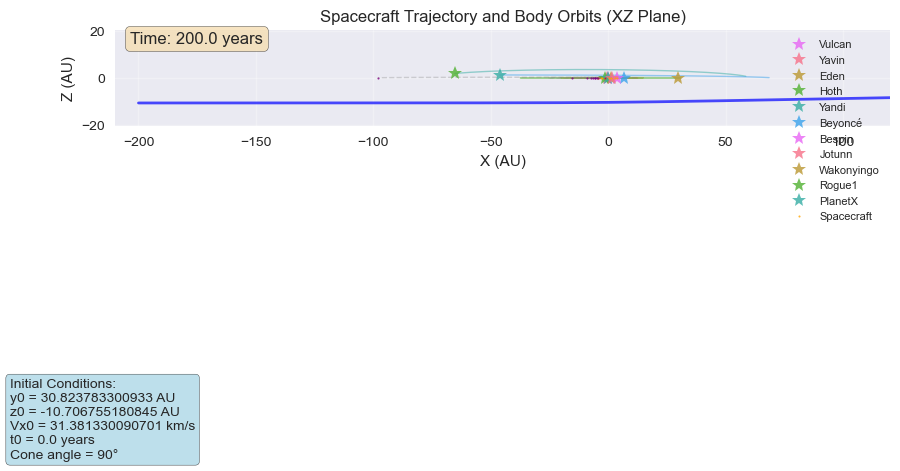

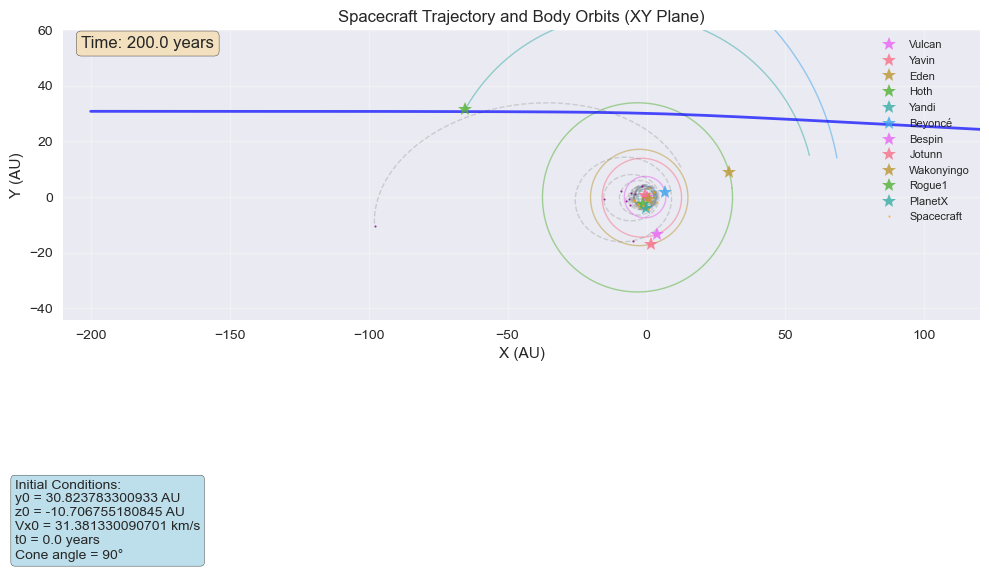

Final distance from Altaira: 1122.80 AU
Final position: (1122.34, -30.39, 10.56) AU
Final distance from Altaira: 137.66 AU
Final position: (-133.73753839953, 30.81246859660, -10.70282497643) AU
Final velocity: (31.45040087388, -0.01325858758, 0.00460541946) km/s
Velocity Planet X at t=10 years: [-1.14048831  4.05859178  0.05063139] km/s
Position Planet X at t=10 years: [66.50341079 22.71560363  0.19110338] AU
Distance from Planet X at t=10 years: 200.7004599661857 AU
V_in : [ 3.14504009e+01 -1.32585876e-02  4.60541946e-03].12f
V_inf_in : [32.59088919 -4.07185036 -0.04602597].12f
V_out : [ 3.14178737e+01 -9.19469902e-03 -1.41712789e+00].12f
V_inf_out : [32.55836203 -4.06778647 -1.46775928].12f
V_inf_mag : 32.84430151315051.12f

TRAJECTORY ANALYSIS
Final position: (1122.34, -30.39, 10.56) AU
Final velocity: (31.21, -1.71, 0.59) km/s
Final speed: 31.26 km/s
Total simulation time: 200.0 years
Minimum distance from Altaira: 31.86 AU
Maximum distance from Altaira: 1122.80 AU

Close approache

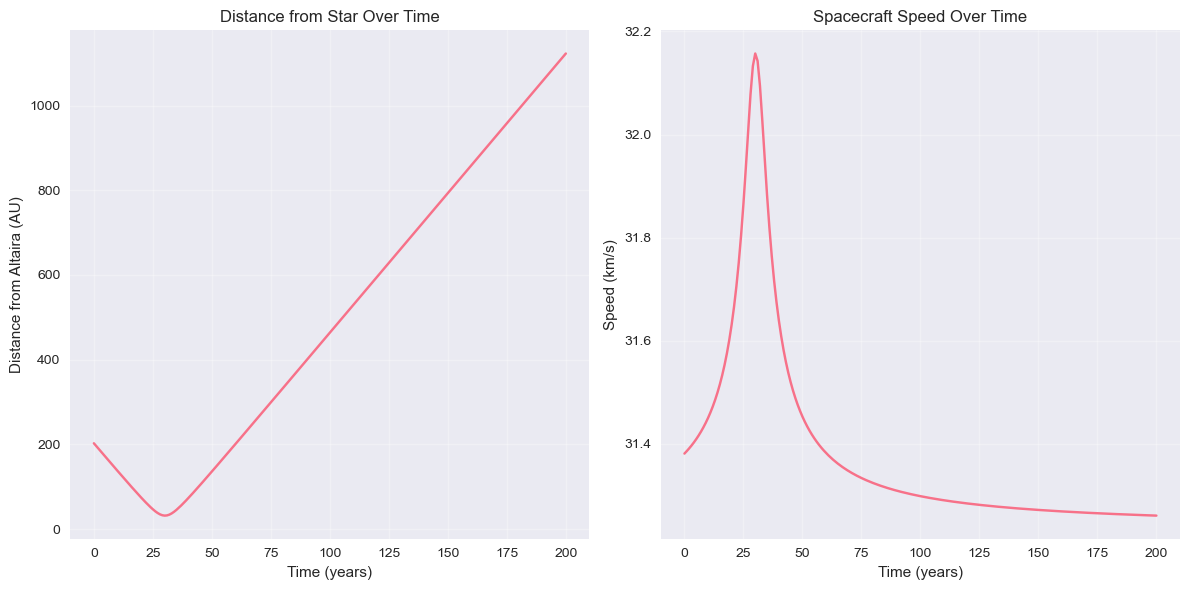


SIMULATION COMPLETE


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings('ignore')

# Constants
AU = 149597870.691  # km
MU_ALTAIRA = 139348062043.343  # km³/s²
YEAR_SEC = 365.25 * 86400  # seconds

class GTOC13Visualizer:
    def __init__(self, planets_df, asteroids_df, comets_df):
        self.planets = planets_df
        self.asteroids = asteroids_df
        self.comets = comets_df

        # Solar sail parameters
        self.sail_C = 9.08e-6  # N/m²
        self.sail_A = 1e6      # m²
        self.sail_m = 1000     # kg
        self.sail_r0 = AU      # km
        
        # Problem constraints
        self.max_time = 200 * YEAR_SEC  # 200 years in seconds
        self.min_flyby_altitude_ratio = 0.1
        self.max_flyby_altitude_ratio = 100.0
        self.min_perihelion = 0.05 * AU  # 0.05 AU in km
        self.single_low_perihelion = 0.01 * AU  # 0.01 AU in km
        self.min_flyby_interval_ratio = 1/3  # Minimum interval between successive flybys of same body
        # Body information dictionary
        self.bodies = {}
        # Add planets
        for _, planet in self.planets.iterrows():
            self.bodies[planet['#Planet ID']] = {
                'name': planet['Name'],
                'GM': planet['GM (km3/s2)'],
                'radius': planet['Radius (km)'],
                'weight': planet['Weight ()'],
                'a': planet['Semi-Major Axis (km)'],
                'e': planet['Eccentricity ()'],
                'i': np.radians(planet['Inclination (deg)']),
                'Omega': np.radians(planet['Longitude of the Ascending Node (deg)']),
                'omega': np.radians(planet['Argument of Periapsis (deg)']),
                'M0': np.radians(planet['Mean Anomaly at t=0 (deg)']),
                'type': 'Planet'
            }

        # Add a sample of asteroids
        asteroid_sample = self.asteroids.sample(n=min(10, len(self.asteroids)), random_state=42) # Consistent sample
        for _, asteroid in asteroid_sample.iterrows():
             self.bodies[asteroid['#Asteroid ID']] = {
                'name': f"Ast {asteroid['#Asteroid ID']}",
                'GM': 0.0, # Assume massless for visualization
                'radius': 0.0,
                'weight': asteroid['Weight ()'],
                'a': asteroid['Semi-Major Axis (km)'],
                'e': asteroid['Eccentricity ()'],
                'i': np.radians(asteroid['Inclination (deg)']),
                'Omega': np.radians(asteroid['Longitude of the Ascending Node (deg)']),
                'omega': np.radians(asteroid['Argument of Periapsis (deg)']), # Corrected column name
                'M0': np.radians(asteroid['Mean Anomaly at t=0']), # Corrected column name
                'type': 'Asteroid'
            }

        # Add a sample of comets
        comet_sample = self.comets.sample(n=min(10, len(self.comets)), random_state=42) # Consistent sample
        for _, comet in comet_sample.iterrows():
             self.bodies[comet['# Comet ID']] = {
                'name': f"Com {comet['# Comet ID']}",
                'GM': 0.0, # Assume massless for visualization
                'radius': 0.0,
                'weight': comet['Weight ()'],
                'a': comet['Semi-Major Axis (km)'],
                'e': comet['Eccentricity ()'],
                'i': np.radians(comet['Inclination (deg)']),
                'Omega': np.radians(comet['Longitude of the Ascending Node (deg)']),
                'omega': np.radians(comet['Argument of Periapsis (deg)']), # Corrected column name
                'M0': np.radians(comet['Mean Anomaly at t=0 (deg)']), # Corrected column name
                'type': 'Comet'
            }

        # Default initial conditions
        self.default_initial_state = {
            'y0': 5.0,    # AU
            'z0': 2.0,    # AU
            'Vx0': 30.0,  # km/s
            't0': 0.0     # years
        }

        # Animation parameters
        self.time_step = 1.0  # years (fixed as requested)
        self.total_time = 200  # years (fixed as requested)

    def solar_sail_acceleration(self, r_sc, cone_angle_deg=0):
        """Calculate solar sail acceleration vector"""
        r_norm = np.linalg.norm(r_sc)
        r_hat = r_sc / r_norm

        alpha_rad = np.radians(cone_angle_deg)
        n_hat = r_hat * np.cos(alpha_rad)

        accel_mag = (2 * self.sail_C * self.sail_A / self.sail_m) * (self.sail_r0 / r_norm)**2 * (np.cos(alpha_rad))**2
        accel_vector = accel_mag * n_hat

        return accel_vector * 1e-3  # Convert to km/s²

    def spacecraft_dynamics(self, t, y, cone_angle_deg=0):
        """Spacecraft dynamics with solar sail"""
        r = y[:3]  # Position vector (km)
        v = y[3:]  # Velocity vector (km/s)

        # Gravitational acceleration from Altaira
        r_norm = np.linalg.norm(r)
        a_gravity = -MU_ALTAIRA * r / r_norm**3

        # Solar sail acceleration
        a_sail = self.solar_sail_acceleration(r, cone_angle_deg)

        # Total acceleration
        a_total = a_gravity + a_sail

        return np.concatenate([v, a_total])

    def kepler_solver(self, M, e, tolerance=1e-12, max_iter=50):
        """Solve Kepler's equation M = E - e*sin(E) for eccentric anomaly E"""
        E = M  # Initial guess
        for _ in range(max_iter):
            delta_E = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
            E -= delta_E
            if abs(delta_E) < tolerance:
                break
        return E

    def body_state_at_time(self, body_id, t):
        """Get body state (position, velocity) at time t using Keplerian propagation"""
        body = self.bodies[body_id]
        a, e, i, Omega, omega, M0 = body['a'], body['e'], body['i'], body['Omega'], body['omega'], body['M0']
        i=i*DEG2RAD
        Omega=Omega*DEG2RAD
        omega=omega*DEG2RAD
        M0=M0*DEG2RAD
        # Mean motion
        n = np.sqrt(MU_ALTAIRA / a**3)

        # Mean anomaly at time t
        M = M0 + n * t

        # Solve for eccentric anomaly
        E = self.kepler_solver(M, e)

        # True anomaly
        theta = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E/2), np.sqrt(1 - e) * np.cos(E/2))

        # Distance
        r = a * (1 - e * np.cos(E))

        # Position in orbital plane
        x_orb = r * np.cos(theta)
        y_orb = r * np.sin(theta)

        # Velocity in orbital plane
        p = a * (1 - e**2)
        h = np.sqrt(MU_ALTAIRA * p)
        vx_orb = -np.sqrt(MU_ALTAIRA / p) * np.sin(theta)
        vy_orb = np.sqrt(MU_ALTAIRA / p) * (e + np.cos(theta))

        # Rotation matrices
        R_Omega = np.array([
            [np.cos(Omega), -np.sin(Omega), 0],
            [np.sin(Omega), np.cos(Omega), 0],
            [0, 0, 1]
        ])

        R_i = np.array([
            [1, 0, 0],
            [0, np.cos(i), -np.sin(i)],
            [0, np.sin(i), np.cos(i)]
        ])

        R_omega = np.array([
            [np.cos(omega), -np.sin(omega), 0],
            [np.sin(omega), np.cos(omega), 0],
            [0, 0, 1]
        ])

        # Combined rotation
        R = R_Omega @ R_i @ R_omega

        # Transform to inertial frame
        pos_orb = np.array([x_orb, y_orb, 0])
        vel_orb = np.array([vx_orb, vy_orb, 0])

        pos = R @ pos_orb
        vel = R @ vel_orb

        return pos, vel

    def propagate_trajectory(self, initial_state, cone_angle_deg=0, time_step_years=1.0, total_time_years=100):
        """Propagate spacecraft trajectory with given initial conditions"""
        # Extract initial conditions
        y0 = initial_state['y0'] * AU
        z0 = initial_state['z0'] * AU
        Vx0 = initial_state['Vx0']
        t0 = initial_state['t0'] * YEAR_SEC

        # Initial position and velocity
        r0 = np.array([-200 * AU, y0, z0])
        v0 = np.array([Vx0, 0, 0])

        y0_state = np.concatenate([r0, v0])

        # Time points for propagation (in seconds)
        time_step_sec = time_step_years * YEAR_SEC
        total_time_sec = total_time_years * YEAR_SEC
        t_eval = np.arange(t0, t0 + total_time_sec + time_step_sec, time_step_sec) # Add a small step to ensure last point is included

        # Integrate trajectory
        sol = solve_ivp(
            lambda t, y: self.spacecraft_dynamics(t, y, cone_angle_deg),
            [t0, t0 + total_time_sec],
            y0_state,
            method='RK45',
            t_eval=t_eval,
            rtol=1e-14,
            atol=1e-14
        )

        if not sol.success:
            # Check if integration stopped early but still has points
            if sol.status == 1: # Integration successful to the end of interval
                 print(f"Integration successful over requested interval.")
            elif sol.status == 0: # Integration successful to the end of t_eval
                 print(f"Integration successful over specified time points.")
            else:
                raise RuntimeError(f"Integration failed: {sol.message}")


        # Convert to AU for plotting
        positions_au = sol.y[:3].T / AU
        velocities = sol.y[3:].T
        times_years = (sol.t - t0) / YEAR_SEC

        return positions_au, velocities, times_years

    def get_body_positions(self, time_years, body_ids=None):
        """Get positions of bodies at given time"""
        if body_ids is None:
            body_ids = list(self.bodies.keys())

        body_positions = {}
        t_sec = time_years * YEAR_SEC

        for body_id in body_ids:
            pos, _ = self.body_state_at_time(body_id, t_sec)
            body_positions[body_id] = pos / AU

        return body_positions
    
    
    def patched_conic_flyby(self, v_in, v_planet, body_id, flyby_altitude_ratio):
        """Perform patched-conic gravity assist calculation"""
        body = self.bodies[body_id]

        # Incoming V_infinity vector
        v_inf_in = v_in - v_planet
        v_inf_mag = np.linalg.norm(v_inf_in)

        # Check if body is massless
        if body['GM'] == 0:
            # Massless body - no gravity assist, velocity remains the same
            return v_in, v_inf_mag

        # Flyby periapsis radius
        r_p = body['radius'] * (1 + flyby_altitude_ratio)

        # Turn angle
        sin_delta_2 = 1 / (1 + (r_p * v_inf_mag**2) / body['GM'])
        delta = 2 * np.arcsin(sin_delta_2)

        # Check flyby altitude constraints
        min_altitude = body['radius'] * self.min_flyby_altitude_ratio
        max_altitude = body['radius'] * self.max_flyby_altitude_ratio
        if r_p < min_altitude or r_p > max_altitude:
            return None, None

        # Create rotation matrix for V_infinity vector
        v_inf_unit = v_inf_in / v_inf_mag

        # Ideally should be a function of relative position and relative velocity
        # Choose a perpendicular vector (arbitrary but consistent)
        if abs(v_inf_unit[0]) > 0.1 or abs(v_inf_unit[1]) > 0.1:
            perp = np.array([-v_inf_unit[1], v_inf_unit[0], 0])
        else:
            perp = np.array([0, -v_inf_unit[2], v_inf_unit[1]])
        perp = perp / np.linalg.norm(perp)

        # Rotation matrix for delta around perp axis
        cos_delta = np.cos(delta)
        sin_delta = np.sin(delta)

        R = (cos_delta * np.eye(3) +
             sin_delta * np.array([
                 [0, -perp[2], perp[1]],
                 [perp[2], 0, -perp[0]],
                 [-perp[1], perp[0], 0]
             ]) +
             (1 - cos_delta) * np.outer(perp, perp))

        # Outgoing V_infinity vector
        v_inf_out = R @ v_inf_in

        # Outgoing velocity
        v_out = v_planet + v_inf_out

        return v_in,v_inf_in,v_out,v_inf_out, v_inf_mag


    def create_animation(self, initial_state=None, cone_angle_deg=0, time_step_years=1.0,
                        total_time_years=200, save_animation=True):
        """Create 2D animation of spacecraft trajectory and body orbits in XZ and XY planes"""

        if initial_state is None:
            initial_state = self.default_initial_state

        # Override animation parameters based on user request
        time_step_years = 1.0
        total_time_years = 200
        save_animation = True


        # Propagate trajectory
        print("Propagating spacecraft trajectory...")
        positions_au, velocities, times_years = self.propagate_trajectory(
            initial_state, cone_angle_deg, time_step_years, total_time_years)

        # Get orbits for all bodies (planets, sample asteroids, sample comets)
        print("Calculating body orbits...")
        body_orbit_points = {}
        body_ids_to_plot = list(self.bodies.keys()) # All bodies in the dictionary
        for body_id in body_ids_to_plot:
            body = self.bodies[body_id]
            # Calculate orbit points over a few periods or the mission time
            # For distant bodies, one period might be very long
            period_yrs = 2 * np.pi * np.sqrt(body['a']**3 / MU_ALTAIRA) / YEAR_SEC if body['a'] > 0 else 1.0
            num_points = 200 # Number of points for each orbit
            t_orbit_eval = np.linspace(0, min(period_yrs, total_time_years) * YEAR_SEC, num_points) # Max 200 yrs or 1 period
            orbit_pos = np.array([self.body_state_at_time(body_id, t)[0] for t in t_orbit_eval]) / AU
            body_orbit_points[body_id] = orbit_pos


        # Set up the figures for XZ and XY plots
        fig_xz, ax_xz = plt.subplots(figsize=(10, 8))
        fig_xy, ax_xy = plt.subplots(figsize=(10, 8))

        # Determine plot limits based on trajectory and orbits
        all_x = positions_au[:, 0]
        all_y = positions_au[:, 1]
        all_z = positions_au[:, 2]

        # Include all orbit points for limits
        for orbit_pos in body_orbit_points.values():
            all_x = np.concatenate((all_x, orbit_pos[:, 0]))
            all_y = np.concatenate((all_y, orbit_pos[:, 1]))
            all_z = np.concatenate((all_z, orbit_pos[:, 2]))

        margin = 10 # AU margin
        x_min, x_max = min(all_x) - margin, max(all_x) + margin
        y_min, y_max = min(all_y) - margin, max(all_y) + margin
        z_min, z_max = min(all_z) - margin, max(all_z) + margin

        # Further limit ranges for better visualization of inner system and SC
        x_min_inner, x_max_inner = -220, 120
        y_min_inner, y_max_inner = -60, 60
        z_min_inner, z_max_inner = -60, 60

        ax_xz.set_xlim(max(x_min, x_min_inner), min(x_max, x_max_inner))
        ax_xz.set_ylim(max(z_min, z_min_inner), min(z_max, z_max_inner))
        ax_xz.set_xlabel('X (AU)')
        ax_xz.set_ylabel('Z (AU)')
        ax_xz.set_title('Spacecraft Trajectory and Body Orbits (XZ Plane)')
        ax_xz.grid(True, alpha=0.3)
        ax_xz.set_aspect('equal')

        ax_xy.set_xlim(max(x_min, x_min_inner), min(x_max, x_max_inner))
        ax_xy.set_ylim(max(y_min, y_min_inner), min(y_max, y_max_inner))
        ax_xy.set_xlabel('X (AU)')
        ax_xy.set_ylabel('Y (AU)')
        ax_xy.set_title('Spacecraft Trajectory and Body Orbits (XY Plane)')
        ax_xy.grid(True, alpha=0.3)
        ax_xy.set_aspect('equal')

        # Plot body orbits on both plots
        for body_id, orbit_pos in body_orbit_points.items():
            body = self.bodies[body_id]
            linestyle = '--' if body['type'] in ['Asteroid', 'Comet'] else '-'
            alpha = 0.3 if body['type'] in ['Asteroid', 'Comet'] else 0.5
            color = 'gray' if body['type'] in ['Asteroid', 'Comet'] else None # Use default colors for planets

            ax_xz.plot(orbit_pos[:, 0], orbit_pos[:, 2], linestyle, alpha=alpha, linewidth=1, color=color)
            ax_xy.plot(orbit_pos[:, 0], orbit_pos[:, 1], linestyle, alpha=alpha, linewidth=1, color=color)


        # Create plot elements for animation (XZ plane)
        trajectory_line_xz, = ax_xz.plot([], [], 'b-', linewidth=2, alpha=0.7, label='Spacecraft Trajectory')
        current_point_xz, = ax_xz.plot([], [], 'ro', markersize=8, label='Spacecraft')
        time_text_xz = ax_xz.text(0.02, 0.98, '', transform=ax_xz.transAxes, fontsize=12,
                               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        # Create plot elements for animation (XY plane)
        trajectory_line_xy, = ax_xy.plot([], [], 'b-', linewidth=2, alpha=0.7, label='Spacecraft Trajectory')
        current_point_xy, = ax_xy.plot([], [], 'ro', markersize=8, label='Spacecraft')
        time_text_xy = ax_xy.text(0.02, 0.98, '', transform=ax_xy.transAxes, fontsize=12,
                               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        # Body markers (show current position of bodies)
        body_markers_xz = {}
        body_markers_xy = {}
        for body_id in body_ids_to_plot:
             body = self.bodies[body_id]
             marker = '*' if body['type'] == 'Planet' else '.'
             markersize = 10 if body['type'] == 'Planet' else 3
             color = 'orange' if body['type'] == 'Asteroid' else ('purple' if body['type'] == 'Comet' else None) # Use default colors for planets

             body_markers_xz[body_id], = ax_xz.plot([], [], marker, markersize=markersize,
                                                   label=body['name'] if body['type'] == 'Planet' else '', alpha=0.8, color=color)
             body_markers_xy[body_id], = ax_xy.plot([], [], marker, markersize=markersize,
                                                   label=body['name'] if body['type'] == 'Planet' else '', alpha=0.8, color=color)


        # Add legend for planets and spacecraft (same legend for both plots)
        legend_handles = [h for h in [body_markers_xz[body_id] for body_id in self.bodies] if h.get_label()] + [current_point_xz]
        legend_labels = [l for l in [self.bodies[body_id]['name'] if self.bodies[body_id]['type'] == 'Planet' else '' for body_id in self.bodies] if l] + ['Spacecraft']

        unique_labels = {}
        for h, l in zip(legend_handles, legend_labels):
            if l not in unique_labels:
                unique_labels[l] = h

        ax_xz.legend(unique_labels.values(), unique_labels.keys(), loc='upper right', fontsize=8)
        ax_xy.legend(unique_labels.values(), unique_labels.keys(), loc='upper right', fontsize=8)


        # Add initial conditions text (to both figures or just one)
        ic_text = f"Initial Conditions:\n"
        ic_text += f"y0 = {initial_state['y0']} AU\n"
        ic_text += f"z0 = {initial_state['z0']} AU\n"
        ic_text += f"Vx0 = {initial_state['Vx0']} km/s\n"
        ic_text += f"t0 = {initial_state['t0']} years\n"
        ic_text += f"Cone angle = {cone_angle_deg}°"

        fig_xz.text(0.02, 0.02, ic_text, transform=fig_xz.transFigure, fontsize=10, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        fig_xy.text(0.02, 0.02, ic_text, transform=fig_xy.transFigure, fontsize=10, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))


        def animate(frame):
            # Current time in simulation years
            current_sim_time = times_years[frame]
            # Absolute time (since t=0 in input data)
            absolute_time = current_sim_time + initial_state['t0']

            # Update trajectory line (show history up to current point)
            trajectory_line_xz.set_data(positions_au[:frame+1, 0], positions_au[:frame+1, 2])
            trajectory_line_xy.set_data(positions_au[:frame+1, 0], positions_au[:frame+1, 1])


            # Update current spacecraft position
            current_point_xz.set_data([positions_au[frame, 0]], [positions_au[frame, 2]])
            current_point_xy.set_data([positions_au[frame, 0]], [positions_au[frame, 1]])

            # Update time text
            time_str = f'Time: {current_sim_time:.1f} years'
            time_text_xz.set_text(time_str)
            time_text_xy.set_text(time_str)


            # Update body positions
            body_current_positions = self.get_body_positions(absolute_time, body_ids_to_plot)

            for body_id in body_ids_to_plot:
                 if body_id in body_current_positions:
                     pos = body_current_positions[body_id]
                     body_markers_xz[body_id].set_data([pos[0]], [pos[2]])
                     body_markers_xy[body_id].set_data([pos[0]], [pos[1]])


            return ([trajectory_line_xz, current_point_xz, time_text_xz] + list(body_markers_xz.values()) +
                    [trajectory_line_xy, current_point_xy, time_text_xy] + list(body_markers_xy.values()))


        # Create animations
        print("Creating animations...")
        anim_xz = FuncAnimation(fig_xz, animate, frames=len(times_years),interval=100, blit=True, repeat=False
        )

        anim_xy = FuncAnimation(fig_xy, animate, frames=len(times_years),interval=100, blit=True, repeat=False
        )

        plt.tight_layout()

        if save_animation:
            print(f"Saving XZ animation to gtoc13_animation_xz.gif...")
            try:
                anim_xz.save("gtoc13_animation_xz.gif", writer='pillow', fps=10, dpi=100)
                print("XZ Animation saved!")
            except Exception as e:
                print(f"Error saving XZ animation: {e}")
                print("Please check if 'pillow' writer is available or try another format.")

            print(f"Saving XY animation to gtoc13_animation_xy.gif...")
            try:
                anim_xy.save("gtoc13_animation_xy.gif", writer='pillow', fps=10, dpi=100)
                print("XY Animation saved!")
            except Exception as e:
                print(f"Error saving XY animation: {e}")
                print("Please check if 'pillow' writer is available or try another format.")


        plt.show()

        return (anim_xz, anim_xy), positions_au, velocities, times_years

    def interactive_simulation(self):
        """Run an interactive simulation with user-defined parameters"""
        print("GTOC13 Spacecraft Trajectory Simulator")
        print("="*50)

        # Get user input or use defaults
        print("Enter initial conditions (press Enter for defaults):")

        try:
            y0 = float(input(f"Initial y position [AU] (default: {self.default_initial_state['y0']}): ") or self.default_initial_state['y0'])
            z0 = float(input(f"Initial z position [AU] (default: {self.default_initial_state['z0']}): ") or self.default_initial_state['z0'])
            Vx0 = float(input(f"Initial Vx velocity [km/s] (default: {self.default_initial_state['Vx0']}): ") or self.default_initial_state['Vx0'])
            t0 = float(input(f"Initial time [years] (default: {self.default_initial_state['t0']}): ") or self.default_initial_state['t0'])
            cone_angle = float(input("Sail cone angle [deg] (default: 0): ") or 0)
            # time_step and total_time are fixed in create_animation now
            save_anim = input("Save animation? (y/n, default: y): ").lower().strip() != 'n' # Default to saving

        except ValueError:
            print("Invalid input. Using default values.")
            y0, z0, Vx0, t0 = self.default_initial_state.values()
            cone_angle, save_anim = 0, True # Default save to True

        initial_state = {
            'y0': y0,
            'z0': z0,
            'Vx0': Vx0,
            't0': t0
        }

        print(f"\nRunning simulation with:")
        print(f"  Initial position: y={y0} AU, z={z0} AU")
        print(f"  Initial velocity: Vx={Vx0} km/s")
        print(f"  Initial time: t0={t0} years")
        print(f"  Sail cone angle: {cone_angle}°")
        print(f"  Time step: {self.time_step} years (fixed)")
        print(f"  Total time: {self.total_time} years (fixed)")

        # Run animation
        (anim_xz, anim_xy), positions, velocities, times = self.create_animation(
            initial_state=initial_state,
            cone_angle_deg=cone_angle,
            # time_step_years and total_time_years are now defaults in create_animation
            save_animation=save_anim
        )

        return (anim_xz, anim_xy), positions_au, velocities, times_years

# Additional utility functions for analysis
def analyze_trajectory(positions_au, velocities, times_years, visualizer):
    """Analyze the trajectory results"""
    print("\n" + "="*50)
    print("TRAJECTORY ANALYSIS")
    print("="*50)

    # Calculate basic statistics
    final_pos = positions_au[-1]
    final_vel = velocities[-1]
    final_speed = np.linalg.norm(final_vel)

    print(f"Final position: ({final_pos[0]:.2f}, {final_pos[1]:.2f}, {final_pos[2]:.2f}) AU")
    print(f"Final velocity: ({final_vel[0]:.2f}, {final_vel[1]:.2f}, {final_vel[2]:.2f}) km/s")
    print(f"Final speed: {final_speed:.2f} km/s")
    print(f"Total simulation time: {times_years[-1]:.1f} years")

    # Calculate distance from Altaira over time
    distances = np.linalg.norm(positions_au, axis=1)
    min_distance = np.min(distances)
    max_distance = np.max(distances)

    print(f"Minimum distance from Altaira: {min_distance:.2f} AU")
    print(f"Maximum distance from Altaira: {max_distance:.2f} AU")

    # Check for close approaches to planets
    print("\nClose approaches to planets:")
    # Get planet IDs
    planet_ids = [body_id for body_id, body in visualizer.bodies.items() if body['type'] == 'Planet']

    for time_idx, time_year in enumerate(times_years): # Check every point as time step is large now
        sc_pos = positions_au[time_idx]
        absolute_time = time_year + visualizer.default_initial_state['t0'] # Use initial t0

        for planet_id in planet_ids:
            try:
                planet_pos, _ = visualizer.body_state_at_time(planet_id, absolute_time * YEAR_SEC) # Pass time in seconds
                planet_pos_au = planet_pos / AU
                distance = np.linalg.norm(sc_pos - planet_pos_au) # Fixed np.linalg

                # Consider close approach if within 5 AU or a few planetary radii
                body = visualizer.bodies[planet_id]
                min_approach_dist_au = max(5.0, body['radius'] * 10 / AU) # 10x radius or 5 AU, whichever is larger
                if distance < min_approach_dist_au:
                    print(f"  {body['name']}: {distance:.2f} AU at {time_year:.1f} years")
            except Exception as e:
                 # Handle cases where body state cannot be calculated (e.g., outside valid time range)
                 pass


    # Plot additional analysis (keep basic plots)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Distance from Altaira over time
    axes[0].plot(times_years, distances)
    axes[0].set_xlabel('Time (years)')
    axes[0].set_ylabel('Distance from Altaira (AU)')
    axes[0].set_title('Distance from Star Over Time')
    axes[0].grid(True, alpha=0.3)

    # Speed over time
    speeds = np.linalg.norm(velocities, axis=1)
    axes[1].plot(times_years, speeds)
    axes[1].set_xlabel('Time (years)')
    axes[1].set_ylabel('Speed (km/s)')
    axes[1].set_title('Spacecraft Speed Over Time')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Main execution
def main():
    # Load data
    planets = pd.read_csv('./content/gtoc13_planets.csv', encoding='latin1')
    asteroids = pd.read_csv('./content/gtoc13_asteroids.csv', encoding='latin1')
    comets = pd.read_csv('./content/gtoc13_comets.csv', encoding='latin1')

    # Print column names for debugging
    print("Asteroids DataFrame columns:", asteroids.columns.tolist())
    print("Comets DataFrame columns:", comets.columns.tolist())


    # Initialize visualizer with all dataframes
    visualizer = GTOC13Visualizer(planets, asteroids, comets)

    print("GTOC13 2D Spacecraft Trajectory Animation")
    print("Showing XZ and XY planes")
    print("="*50)

    # Choose mode
    print("Choose simulation mode:")
    print("1. Interactive (enter parameters)")
    print("2. Default demonstration")

    # choice = input("Enter choice (1 or 2, default: 2): ").strip()
    choice="2"
    if choice == "1":
        # Interactive mode
        (anim_xz, anim_xy), positions, velocities, times = visualizer.interactive_simulation()

        # Analyze results
        analyze_trajectory(positions, velocities, times, visualizer)

    else:
        # Default demonstration with a scenario
        scenario = {
            'name': 'Default 200 Year Animation',
            # 'initial_state': {'y0': 4611083599.094406/AU, 'z0': -1601676006.258477/AU, 'Vx0': 31.382901, 't0': 0.0},
                        'initial_state': {'y0': 30.823783300933 , 'z0':        -10.706755180845  , 'Vx0': 31.381330090701, 't0': 0.0},
                 
                  'cone_angle': 90,
            # time_step and total_time are fixed in create_animation now
        }

        print(f"\n📊 Running Scenario: {scenario['name']}")
        print("-" * 40)

        (anim_xz, anim_xy), positions, velocities, times = visualizer.create_animation(
            initial_state=scenario['initial_state'],
            cone_angle_deg=scenario['cone_angle'],
            # time_step_years and total_time_years are now defaults in create_animation
            save_animation=True # Default to saving the animation
        )

        # Quick analysis
        final_pos = positions[-1]
        final_dist = np.linalg.norm(final_pos)
        print(f"Final distance from Altaira: {final_dist:.2f} AU")
        print(f"Final position: ({final_pos[0]:.2f}, {final_pos[1]:.2f}, {final_pos[2]:.2f}) AU")

        final_pos = positions[10]
        final_vel = velocities[10]
        final_dist = np.linalg.norm(final_pos)
        print(f"Final distance from Altaira: {final_dist:.2f} AU")
        print(f"Final position: ({final_pos[0]:.11f}, {final_pos[1]:.11f}, {final_pos[2]:.11f}) AU")
        print(f"Final velocity: ({final_vel[0]:.11f}, {final_vel[1]:.11f}, {final_vel[2]:.11f}) km/s")
        print(f"Velocity Planet X at t=10 years: {visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[1]} km/s")
        print(f"Position Planet X at t=10 years: {visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[0] / AU} AU")
        print(f"Distance from Planet X at t=10 years: {np.linalg.norm(positions[10] - (visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[0] / AU))} AU")
        # print(f"Vinf_out ":visualizer.patched_conic_flyby(
        #     velocities[10],
        #     visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[1],
        #     10,
        #     flyby_altitude=0.1
        # )[0])
        v_in,v_inf_in,v_out,v_inf_out, v_inf_mag=visualizer.patched_conic_flyby(
    velocities[10],
    visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[1],
    10,
    flyby_altitude_ratio=10
    )
        print(f"V_in : {v_in}.12f")
        print(f"V_inf_in : {v_inf_in}.12f")
        print(f"V_out : {v_out}.12f")
        print(f"V_inf_out : {v_inf_out}.12f")
        print(f"V_inf_mag : {v_inf_mag}.12f")
    #     print(f"Vinf_out : {visualizer.patched_conic_flyby(
    # velocities[10],
    # visualizer.body_state_at_time(10, (10 + scenario['initial_state']['t0']) * YEAR_SEC)[1],
    # 10,
    # flyby_altitude_ratio=10
    # )[0]}")

        # Analyze results
        analyze_trajectory(positions, velocities, times, visualizer)


    print("\n" + "="*60)
    print("SIMULATION COMPLETE")
    print("="*60)
if __name__ == "__main__":
   main()

In [29]:
2.6537588105370446e-12*AU

0.0003969966673838228

In [36]:
print(-200*AU,30.823783300933*AU,-10.706755180845*AU,31.381330090701,0,0)

-29919574138.200005 4611172348.460381 -1601707777.064245 31.381330090701 0 0


In [39]:
print(-133.73753839953*AU, 30.81246859660*AU, -10.70282497643*AU)

-20006850976.025536 4609479692.784665 -1601119826.8523803


In [43]:
print(66.50341079*AU, 22.71560363*AU, 0.19110338*AU)

9948768647.872875 3398205934.5087504 28588658.729853038
